# EDA. Телеметрия воздушного движения

ВКР: "Система раннего выявления нестабильности в данных воздушного движения: сравнение методов обнаружения аномалий и прототип мониторинга на данных OpenSky Network".

Датасет: EUROCONTROL PRC 2024 Data Challenge, траектории ADS-B из OpenSky Network плюс ERA5 meteo.
Период: 1-14 ноября 2022 (14 parquet-файлов, ~11 GB).
Репозиторий: [air-traffic-instability-early-warning](https://github.com/Diplomundo/air-traffic-instability-early-warning).

## Структура

1. Подготовка и загрузка данных
2. Базовая статистика и качество данных
3. Агрегация по рейсам
4. Распределения признаков
5. Производные признаки
6. Пространственный анализ
7. Временные паттерны
8. Метеопризнаки
9. Корреляции
10. Предварительный поиск выбросов
11. Сводка по всем файлам
12. Итоги

## 1. Подготовка и загрузка данных

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import gc
import glob
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                     'axes.titlesize': 14, 'axes.labelsize': 12,})

print('Настройка завершена.')

Настройка завершена.


In [ ]:
DATA_DIR = '/content/drive/MyDrive/OSN - parquets'

parquet_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.parquet')))
print(f'Found {len(parquet_files)} parquet files:')
for f in parquet_files:
    size_mb = os.path.getsize(f) / 1e6
    print(f'  {os.path.basename(f):>20s}  {size_mb:>8.1f} MB')

Found 14 parquet files:
                        2022-11-01.parquet     797.3 MB
                        2022-11-02.parquet     806.4 MB
                        2022-11-03.parquet     844.9 MB
                        2022-11-04.parquet     846.6 MB
                        2022-11-05.parquet     804.7 MB
                        2022-11-06.parquet     876.8 MB
                        2022-11-07.parquet     814.0 MB
                        2022-11-08.parquet     738.7 MB
                        2022-11-09.parquet     722.2 MB
                        2022-11-10.parquet     801.8 MB
                        2022-11-11.parquet     809.5 MB
                        2022-11-12.parquet     736.9 MB
                        2022-11-13.parquet     822.1 MB
                        2022-11-14.parquet     790.1 MB


In [ ]:
# Грузим один файл для EDA, остальные потом агрегируем
# По памяти комфортно от 20 GB ОЗУ

SAMPLE_FILE = parquet_files[0]  # первый день
print(f'Loading sample file: {os.path.basename(SAMPLE_FILE)}')

df = pd.read_parquet(SAMPLE_FILE)
print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Loading sample file: 2022-11-01.parquet
Shape: (16684798, 13)
Memory: 1735.2 MB


## 2. Базовая статистика и качество данных

In [ ]:
print('Data Types')
print(df.dtypes)
print()
print('First 5 Rows')
df.head()

=== Data Types ===
flight_id                            int64
timestamp              datetime64[ns, UTC]
latitude                           float64
longitude                          float64
altitude                           float64
groundspeed                        float64
track                              float64
vertical_rate                      float64
icao24                               int64
u_component_of_wind                float64
v_component_of_wind                float64
temperature                        float64
specific_humidity                  float64
dtype: object

=== First 5 Rows ===


,flight_id,timestamp,latitude,longitude,altitude,groundspeed,track,vertical_rate,icao24,u_component_of_wind,v_component_of_wind,temperature,specific_humidity
0,256680864,2022-11-01 00:41:27+00:00,35.110582,-81.080246,6375.0,NaN,NaN,NaN,256680864,12.249368,11.981286,282.243989,0.007250
1,256680864,2022-11-01 00:41:28+00:00,35.110582,-81.080246,6375.0,NaN,NaN,NaN,256680864,12.249430,11.981180,282.243925,0.007250
2,256680864,2022-11-01 00:41:29+00:00,35.110582,-81.080246,6375.0,248.0,255.515266,2816.0,256680864,12.249491,11.981075,282.243861,0.007251
3,256680864,2022-11-01 00:41:30+00:00,35.110582,-81.080246,6375.0,248.0,255.515266,2816.0,256680864,12.249552,11.980969,282.243798,0.007251
4,256680864,2022-11-01 00:41:31+00:00,35.110582,-81.080246,6375.0,248.0,255.515266,2816.0,256680864,12.249613,11.980863,282.243734,0.007251


In [ ]:
print('Descriptive Statistics')
df.describe().round(2)

=== Descriptive Statistics ===


,flight_id,latitude,longitude,altitude,groundspeed,track,vertical_rate,icao24,u_component_of_wind,v_component_of_wind,temperature,specific_humidity
count,1.668480e+07,16684798.00,16684798.00,16684798.00,16632090.00,16632090.00,16632090.00,1.668480e+07,16684798.00,16684798.00,16684798.00,16684798.00
mean,2.566924e+08,46.29,5.49,27904.86,399.00,186.34,-27.04,2.566924e+08,12.78,3.99,233.85,0.00
std,6.760660e+03,8.35,30.58,12252.47,99.76,102.27,1096.76,6.760660e+03,12.06,11.20,24.71,0.00
min,2.566809e+08,-34.21,-123.61,-1200.00,0.00,0.00,-28672.00,2.566809e+08,-31.63,-35.98,169.47,-0.00
25%,2.566868e+08,41.12,-0.51,20050.00,373.00,100.96,-64.00,2.566868e+08,3.58,-5.42,215.99,0.00
50%,2.566921e+08,46.38,10.73,34000.00,430.00,196.35,0.00,2.566921e+08,12.04,2.33,221.08,0.00
75%,2.566984e+08,51.46,22.06,37000.00,461.00,280.48,0.00,2.566984e+08,21.27,12.76,250.71,0.00
max,2.567043e+08,69.04,140.74,126800.00,1115.00,359.89,32640.00,2.567043e+08,76.15,49.63,302.85,0.02


В файле 16.7 млн ADS-B сообщений за один день (2022-11-01), частота 1 Гц. Каждая строка - одно сообщение: координаты, высота, скорость, курс, вертикальная скорость, плюс метеоданные ERA5 (ветер, температура, влажность).

Пропуски есть только в кинематических параметрах (groundspeed, track, vertical_rate, 0.32%). Это одни и те же строки в начале рейсов: ADS-B транспондер передаёт позицию раньше, чем кинематику. Координаты, высота и метео без пропусков.

Артефакты ADS-B кодирования:
- altitude до 126 800 ft и до −1 200 ft (бит-флипы при декодировании);
- groundspeed до 1 115 kts при реальном потолке ~600 kts для дозвуковой авиации;
- vertical_rate до ±32 000 ft/min, значения кратны 4096, ошибки квантования.

Артефакты отфильтруем на этапе preprocessing.

Охват глобальный (от −34° до +69° широты), но медиана (46°N, 11°E) - Центральная Европа. Неевропейские рейсы отрежем по bbox.

In [ ]:
# Пропуски
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print('Missing Values')
print(missing_report[missing_report['missing_count'] > 0])
if missing_report['missing_count'].sum() == 0:
    print('No missing values!')

=== Missing Values ===
               missing_count  missing_pct
groundspeed            52708         0.32
track                  52708         0.32
vertical_rate          52708         0.32


In [ ]:
# Дубликаты
n_dup = df.duplicated().sum()
print(f'Duplicate rows: {n_dup} ({n_dup / len(df) * 100:.3f}%)')

# По ключу (flight_id, timestamp)
n_dup_key = df.duplicated(subset=['flight_id', 'timestamp']).sum()
print(f'Duplicate (flight_id, timestamp) pairs: {n_dup_key}')

Duplicate rows: 0 (0.000%)
Duplicate (flight_id, timestamp) pairs: 0


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'Временной диапазон {df["timestamp"].min()} - {df["timestamp"].max()}')
print(f'Уникальных рейсов {df["flight_id"].nunique()}')
print(f'Уникальных ICAO24  {df["icao24"].nunique()}')

# В пределах одного файла flight_id == icao24, то есть одно судно = один рейс
assert df['flight_id'].nunique() == df['icao24'].nunique(), \
    'Внимание: flight_id и icao24 не совпадают!'
print('flight_id и icao24 совпадают: каждому рейсу соответствует одно воздушное судно.')

Временной диапазон 2022-11-01 00:21:19+00:00 — 2022-11-02 14:16:09+00:00
Уникальных рейсов 2735
Уникальных ICAO24  2735
flight_id и icao24 совпадают: каждому рейсу соответствует одно воздушное судно.


Пропуски строго одинаковы для groundspeed, track и vertical_rate (52 708 = 0.32%): это одни и те же строки, где кинематика ещё не активирована. Остальные 10 колонок без пропусков.

Дубликатов нет ни по строкам, ни по ключу (flight_id, timestamp).

Временной диапазон файла выходит за пределы суток (до 14:16 следующего дня): рейсы, начавшиеся 1 ноября, заканчиваются 2-го. Между файлами есть перекрытие, при объединении нужна дедупликация.

flight_id и icao24 совпадают (2735 = 2735): в пределах файла каждому рейсу соответствует одно воздушное судно, дополнительной группировки не нужно.

## 3. Агрегация по рейсам

In [ ]:
# Статистика по рейсам
flight_stats = df.groupby('flight_id').agg(
    n_points=('timestamp', 'count'),
    duration_min=('timestamp', lambda x: (x.max() - x.min()).total_seconds() / 60),
    alt_max=('altitude', 'max'),
    alt_min=('altitude', 'min'),
    gs_mean=('groundspeed', 'mean'),
    gs_max=('groundspeed', 'max'),
    vr_mean=('vertical_rate', 'mean'),
    vr_std=('vertical_rate', 'std'),
    lat_start=('latitude', 'first'),
    lon_start=('longitude', 'first'),
    lat_end=('latitude', 'last'),
    lon_end=('longitude', 'last'),
).reset_index()

flight_stats['alt_range'] = flight_stats['alt_max'] - flight_stats['alt_min']

print(f'Flights in this file: {len(flight_stats)}')
flight_stats.describe().round(1)

Flights in this file: 2735


,flight_id,n_points,duration_min,alt_max,alt_min,gs_mean,gs_max,vr_mean,vr_std,lat_start,lon_start,lat_end,lon_end,alt_range
count,2735.0,2735.0,2735.0,2735.0,2735.0,2735.0,2735.0,2735.0,2735.0,2735.0,2735.0,2735.0,2735.0,2735.0
mean,256692566.1,6100.5,137.0,44281.0,971.9,374.9,461.2,-28.3,1124.8,47.2,11.7,47.1,12.2,43309.1
std,6788.1,4309.7,144.1,22785.1,2816.0,56.7,58.7,384.9,433.7,8.5,24.2,8.9,22.8,23268.1
min,256680864.0,352.0,5.8,6075.0,-1200.0,162.6,257.0,-2987.8,47.8,-25.9,-123.4,-32.0,-121.1,225.0
25%,256686428.5,2668.5,46.0,35000.0,75.0,333.5,436.0,-69.3,788.7,41.2,4.8,41.0,4.7,33575.0
50%,256692529.0,4605.0,83.2,37025.0,400.0,384.5,459.0,-20.0,1076.1,47.4,12.6,47.2,12.7,36775.0
75%,256698585.0,8576.0,161.8,39262.5,900.0,416.1,486.0,0.8,1408.3,52.7,28.7,52.9,28.6,39050.0
max,256704287.0,30602.0,830.0,126800.0,37275.0,514.5,1115.0,2043.6,7883.1,68.8,134.6,69.0,138.5,126400.0


В файле 2 735 рейсов, характеристики сильно варьируются.

Длительность и размер. Медиана 83 мин (~1.5 ч), разброс от 6 мин до 830 мин (14 ч), от региональных до дальнемагистральных. Медиана 4 605 точек на рейс при 1 Гц это около 77 мин записи, согласуется с duration_min.

Высотный профиль. Медиана alt_max = 37 025 ft, типичный крейсерский эшелон. Медиана alt_min = 400 ft, большинство рейсов записаны от приземной фазы. Но P75(alt_min) = 900 ft, а max(alt_min) = 37 275 ft: часть рейсов начинаются или заканчиваются на эшелоне (обрезанные траектории на границах покрытия ADS-B).

Скорости. Средний groundspeed 375 kts, нормально для крейсера. Максимум 1 115 kts, артефакт ADS-B (уже замечен выше).

Вертикальная скорость. vr_mean в среднем −28 ft/min (≈ 0): набор и снижение компенсируют друг друга. vr_std медиана 1 076 ft/min, это активность по вертикали. Минимум vr_std = 48 ft/min, практически горизонтальный полёт, скорее всего обрезанный крейсерский сегмент.

Подозрительные рейсы. alt_range min = 225 ft, рейс почти не менял высоту. Либо короткий перелёт, либо фрагмент записи. Фильтрацию проверим ниже.

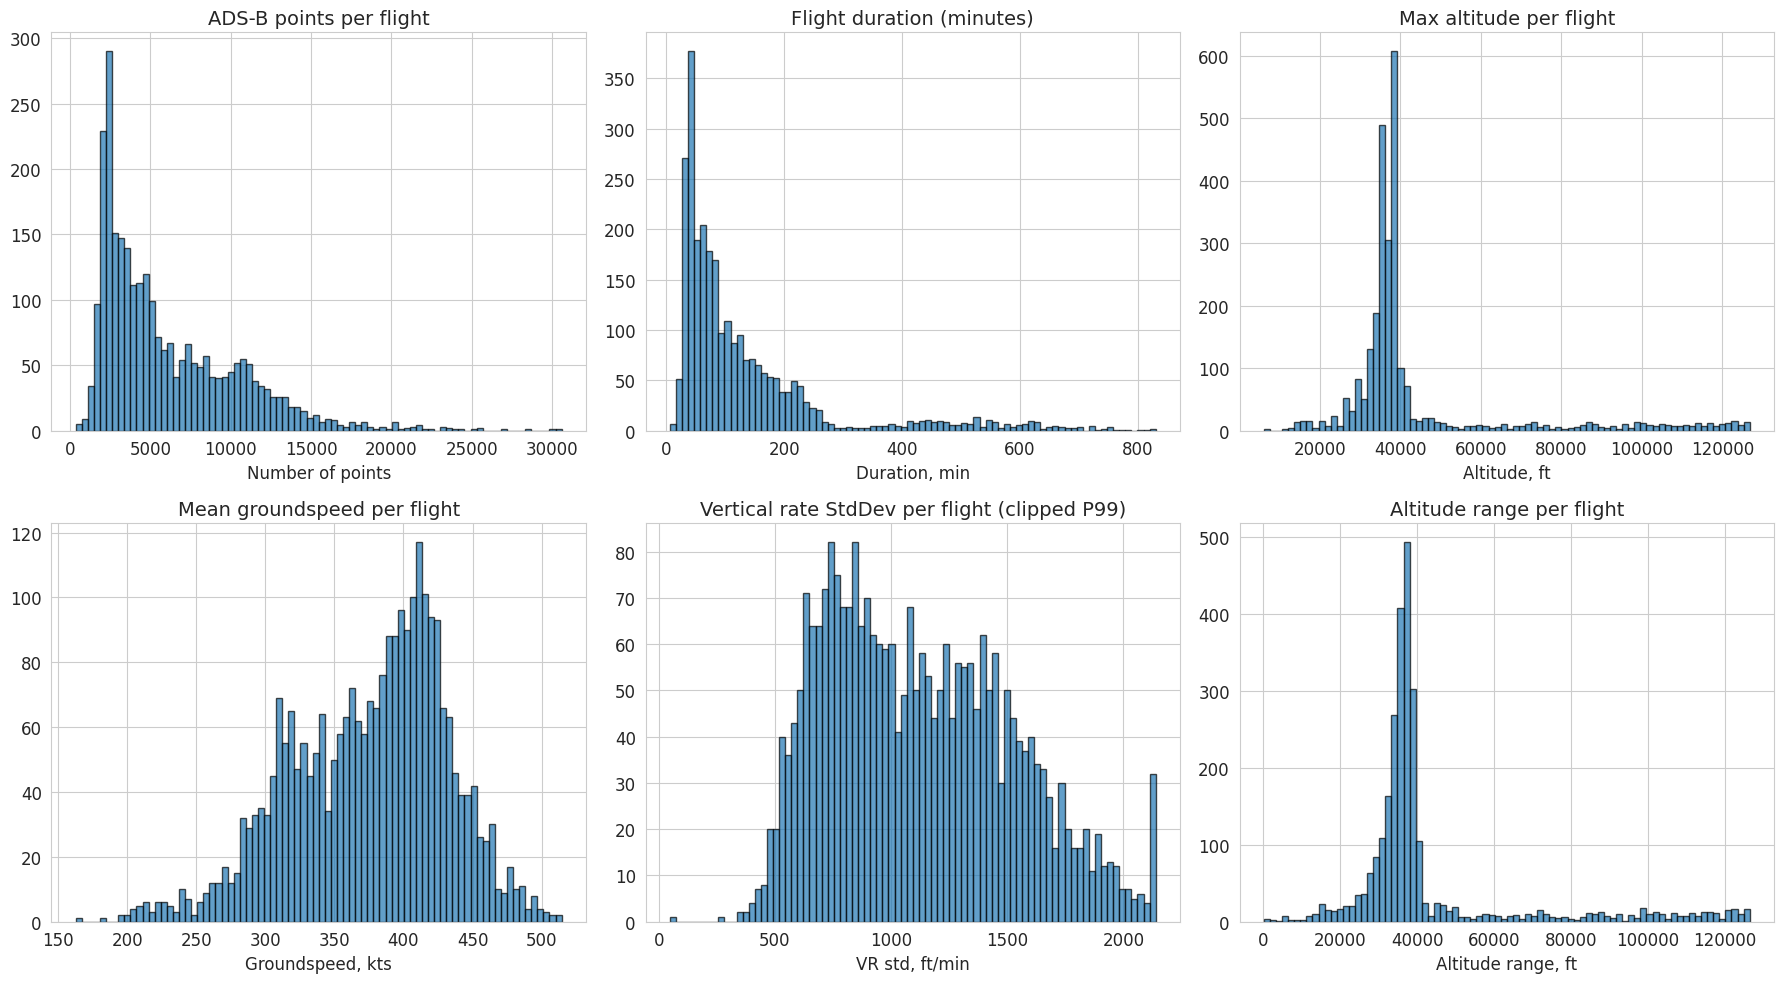

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(flight_stats['n_points'], bins=80, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('ADS-B points per flight')
axes[0, 0].set_xlabel('Number of points')

axes[0, 1].hist(flight_stats['duration_min'], bins=80, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Flight duration (minutes)')
axes[0, 1].set_xlabel('Duration, min')

axes[0, 2].hist(flight_stats['alt_max'], bins=80, edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Max altitude per flight')
axes[0, 2].set_xlabel('Altitude, ft')

axes[1, 0].hist(flight_stats['gs_mean'], bins=80, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Mean groundspeed per flight')
axes[1, 0].set_xlabel('Groundspeed, kts')

axes[1, 1].hist(flight_stats['vr_std'].clip(upper=flight_stats['vr_std'].quantile(0.99)),
                bins=80, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Vertical rate StdDev per flight (clipped P99)')
axes[1, 1].set_xlabel('VR std, ft/min')

axes[1, 2].hist(flight_stats['alt_range'], bins=80, edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Altitude range per flight')
axes[1, 2].set_xlabel('Altitude range, ft')

plt.tight_layout()
plt.savefig('flight_level_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Замечания по распределениям рейсов.

ADS-B points per flight. Правоскошенное распределение с пиком на 2 000-3 000 точек (30-50 мин записи). Длинный хвост до 30 000 точек, дальнемагистральные рейсы. Основная масса короткая и среднемагистральная, типично для внутриевропейского трафика.

Flight duration. Экспоненциально убывающее, пик на 30-60 мин. Большинство региональных (1-2 ч), что согласуется с характером EUROCONTROL (плотная европейская сеть). Хвост до 800 мин (13 ч), межконтинентальные рейсы.

Max altitude. Резкий пик на 35 000-39 000 ft, стандартные крейсерские эшелоны (FL350-FL390). Видны дискретные столбцы: самолёты летят на фиксированных эшелонах, а не на произвольных высотах. Выброс на ~127 000 ft, артефакт ADS-B.

Mean groundspeed. Приближённо нормальное, центр ~380-400 kts. Левый хвост (180-250 kts), турбовинтовые и региональные ВС. Правый хвост (>480 kts), тяжёлые дальнемагистральные на высоких эшелонах с попутным ветром (jet stream).

Vertical rate StdDev. Характеризует активность по вертикали. Похоже на бимодальное: пик ~500-900 ft/min, рейсы записанные в основном на крейсере; пик ~1000-1400 ft/min, полные рейсы с набором и снижением. Рейсы с vr_std < 100, практически горизонтальные фрагменты.

Altitude range. Острый пик на 33 000-38 000 ft, типичный перепад "земля, крейсер, земля" для полных рейсов. Левый хвост (малый alt_range), обрезанные траектории, запись начинается или заканчивается на эшелоне. Правый хвост >60 000 ft, артефакт (alt_max содержит бит-флип на 126 800 ft).

In [ ]:
# Подозрительные рейсы, простая эвристика
suspicious = flight_stats[
    (flight_stats['n_points'] < 10) |
    (flight_stats['duration_min'] < 1) |
    (flight_stats['alt_max'] < 100)
]
print(f'Suspicious flights (< 10 pts OR < 1 min OR max alt < 100 ft): {len(suspicious)} '
      f'({len(suspicious)/len(flight_stats)*100:.2f}%)')
if len(suspicious) > 0:
    print(suspicious.describe().round(1))

Suspicious flights (< 10 pts OR < 1 min OR max alt < 100 ft): 0 (0.00%)


Простая эвристика (менее 10 точек, менее 1 минуты, max alt ниже 100 ft) не выявила подозрительных рейсов. Данные предварительно отфильтрованы на стороне EUROCONTROL: вырожденных и артефактных записей нет. Дополнительная фильтрация по минимальной длине рейса на этом этапе не требуется.

## 4. Распределения признаков

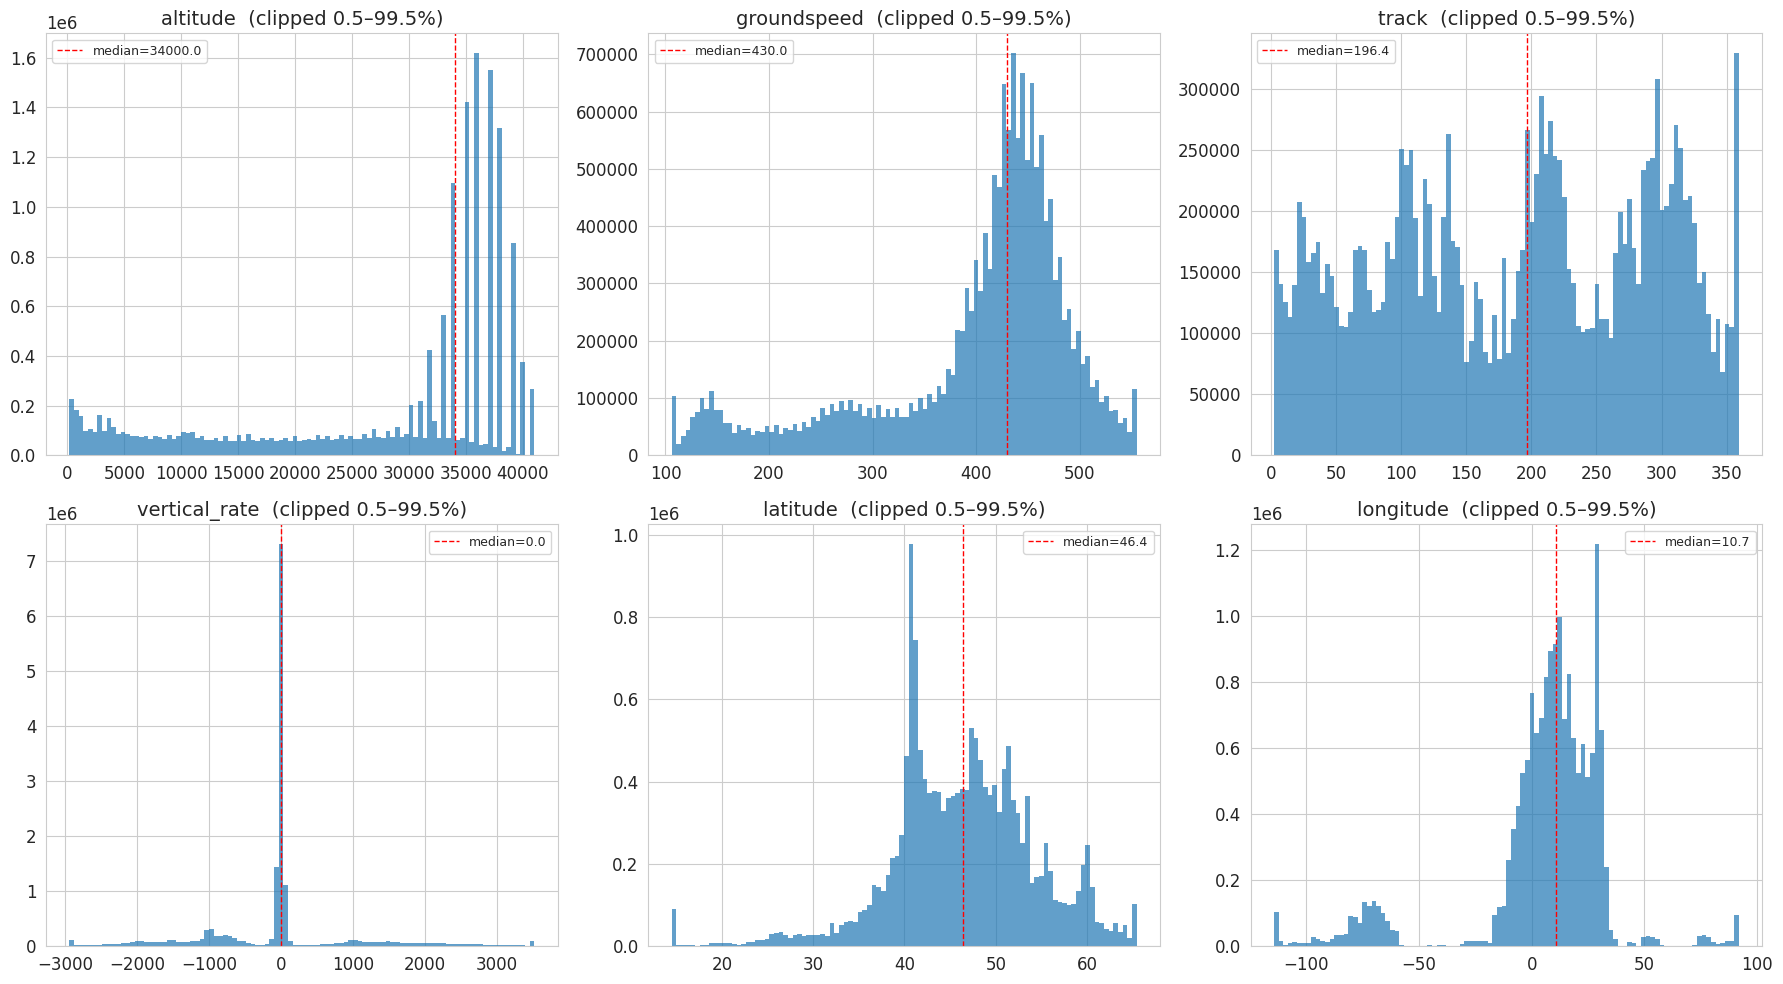

In [ ]:
numeric_cols = ['altitude', 'groundspeed', 'track', 'vertical_rate',
                'latitude', 'longitude']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), numeric_cols):
    data = df[col].dropna()
    # Clip extreme outliers for visualization (0.5% / 99.5%)
    lo, hi = data.quantile(0.005), data.quantile(0.995)
    ax.hist(data.clip(lo, hi), bins=100, edgecolor='none', alpha=0.7)
    ax.set_title(f'{col}  (clipped 0.5–99.5%)')
    ax.axvline(data.median(), color='red', ls='--', lw=1, label=f'median={data.median():.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Замечания по распределениям сырых признаков.

Altitude. Бимодальное с двумя кластерами: приземный (0-5 000 ft, фазы взлёта/посадки/руления) и крейсерский (30 000-40 000 ft). Провал между ними (5 000-25 000 ft) - зоны набора и снижения, которые самолёт проходит быстро. Медиана 34 000 ft: больше половины точек приходится на крейсер.

Groundspeed. Тоже бимодальное: левый пик ~100-200 kts (руление, набор, заход) и правый пик ~420-460 kts (крейсер). Медиана 430 kts. Согласуется с altitude: два режима полёта дают два режима скорости.

Track. Приближённо равномерное (самолёты летят во всех направлениях), но с выраженными пиками на ~30°, ~200° и ~300°. Основные направления европейских воздушных трасс: северо-восток (Скандинавия), юго-запад (Иберия/Африка), северо-запад (Атлантика/Великобритания). Медиана 196°: слабое преобладание юго-западного направления.

Vertical rate. Острый пик на нуле (крейсер = горизонтальный полёт), симметричные хвосты до ±3 000 ft/min. Симметрия означает, что набор и снижение в датасете сбалансированы. Подавляющее большинство точек это горизонтальный полёт (|VR| < 200 ft/min).

Latitude. Концентрация в 40-55°N (Центральная и Западная Европа). Медиана 46.4°N, уровень Швейцарии/Южной Франции. Левый хвост до 20°N: североафриканские и ближневосточные сегменты.

Longitude. Острый пик около 0-15°E (Западная Европа: Франция, Германия, Италия). Медиана 10.7°E. Левый хвост до −120° - трансатлантические рейсы. Правый хвост до 100°E - рейсы в направлении Азии. Оба хвоста отсечём при фильтрации по европейскому bbox.

In [ ]:
# Экстремумы для определения порогов
print('Extreme Values (P0.1 / P1 / P99 / P99.9)')
for col in numeric_cols:
    q = df[col].quantile([0.001, 0.01, 0.99, 0.999])
    print(f'{col:>16s}:  P0.1={q.iloc[0]:>10.1f}  P1={q.iloc[1]:>10.1f}  '
          f'P99={q.iloc[2]:>10.1f}  P99.9={q.iloc[3]:>10.1f}')

=== Extreme Values (P0.1 / P1 / P99 / P99.9) ===
        altitude:  P0.1=       0.0  P1=     425.0  P99=   41000.0  P99.9=   43000.0
     groundspeed:  P0.1=      92.0  P1=     121.0  P99=     545.0  P99.9=     572.0
           track:  P0.1=       0.2  P1=       5.9  P99=     358.9  P99.9=     359.6
   vertical_rate:  P0.1=   -3776.0  P1=   -2624.0  P99=    3136.0  P99.9=    4224.0
        latitude:  P0.1=     -19.7  P1=      22.9  P99=      64.0  P99.9=      68.0
       longitude:  P0.1=    -122.2  P1=     -99.9  P99=      78.5  P99.9=     125.7


Персентили экстремумов отделяют реальные данные от артефактов и задают пороги фильтрации.

Altitude. P99.9 = 43 000 ft, реальный потолок коммерческой авиации. Всё выше (а max = 126 800 ft) это артефакт. Порог ~60 000 ft безопасно отсечёт бит-флипы, не задевая реальные данные. P0.1 = 0 ft, штатное значение (стоянка/руление).

Groundspeed. P99.9 = 572 kts, правдоподобный максимум (тяжёлый самолёт с попутным jet stream). Порог 600 kts отсечёт артефакты (max = 1 115 kts), сохранив все реальные значения.

Vertical rate. P99.9 = 4 224 ft/min, P0.1 = −3 776 ft/min, реальные экстремумы интенсивных наборов/снижений. Значения кратны 64 (квантование ADS-B). Порог ±10 000 ft/min отсечёт артефакты (max = 32 640) с запасом от реальных значений.

Track. P0.1-P99.9 покрывает почти полный круг (0.2°-359.6°), артефактов нет.

Latitude/Longitude. Подтверждают глобальный охват. P1 latitude = 22.9°N (Сахара), P1 longitude = −99.9° (Мексика). При фильтрации по европейскому bbox (lat 35-72°, lon −15-40°) эти хвосты отсечём.

Итого пороги для preprocessing: altitude ∈ [−500, 60 000], groundspeed ≤ 600, |vertical_rate| ≤ 10 000.

## 5. Производные признаки

Это ключевые входы для моделей обнаружения аномалий. Считаем здесь, чтобы посмотреть распределения.

In [ ]:
def compute_derived_features(df):
    """Производные кинематические признаки внутри рейса."""
    df = df.sort_values(['flight_id', 'timestamp']).copy()

    # Шаг времени в секундах
    df['dt'] = df.groupby('flight_id')['timestamp'].diff().dt.total_seconds()

    # Ускорение по путевой скорости (kts/s)
    df['gs_diff'] = df.groupby('flight_id')['groundspeed'].diff()
    df['acceleration'] = df['gs_diff'] / df['dt']

    # Угловая скорость поворота (deg/s), wraparound на 0/360 нормализуем
    track_diff = df.groupby('flight_id')['track'].diff()
    # Нормализация к [-180, 180]
    track_diff = ((track_diff + 180) % 360) - 180
    df['turn_rate'] = track_diff / df['dt']

    # Вертикальное ускорение (ft/min/s)
    df['vr_diff'] = df.groupby('flight_id')['vertical_rate'].diff()
    df['vertical_accel'] = df['vr_diff'] / df['dt']

    # Вертикальная скорость из позиции (ft/s) для сверки с vertical_rate
    df['alt_diff'] = df.groupby('flight_id')['altitude'].diff()
    df['alt_rate_derived'] = df['alt_diff'] / df['dt']  # ft/s

    # Скорость и направление ветра из u/v компонент
    df['wind_speed'] = np.sqrt(df['u_component_of_wind']**2 + df['v_component_of_wind']**2)
    df['wind_dir'] = (np.degrees(np.arctan2(-df['u_component_of_wind'],
                                             -df['v_component_of_wind'])) + 360) % 360

    # Встречная и боковая компоненты ветра (приближение)
    track_rad = np.radians(df['track'])
    wind_rad = np.radians(df['wind_dir'])
    angle_diff = wind_rad - track_rad
    df['headwind'] = df['wind_speed'] * np.cos(angle_diff)   # >0 = встречный
    df['crosswind'] = df['wind_speed'] * np.abs(np.sin(angle_diff))

    # Убираем бесконечности от dt=0
    rate_cols = ['acceleration', 'turn_rate', 'vertical_accel', 'alt_rate_derived']
    for col in rate_cols:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

    return df

df = compute_derived_features(df)
print('Derived features computed.')
print(f'New columns: {[c for c in df.columns if c not in ["flight_id","timestamp","latitude","longitude","altitude","groundspeed","track","vertical_rate","icao24","u_component_of_wind","v_component_of_wind","temperature","specific_humidity"]]}')

Derived features computed.
New columns: ['dt', 'gs_diff', 'acceleration', 'turn_rate', 'vr_diff', 'vertical_accel', 'alt_diff', 'alt_rate_derived', 'wind_speed', 'wind_dir', 'headwind', 'crosswind']


### Производные признаки: что и зачем

Сырые ADS-B параметры (altitude, groundspeed, track, vertical_rate) описывают состояние самолёта в моменте. Для обнаружения аномалий нужна динамика, то есть как резко меняются параметры. Берём конечные разности (df/dt) внутри каждого рейса.

Кинематические производные:
- acceleration (kts/s), изменение groundspeed. Резкое ускорение или торможение - признак нештатной ситуации или интенсивного маневрирования.
- turn_rate (deg/s), изменение курса. Wraparound 0°/360° обработан нормализацией к [−180°, 180°]. Высокий turn_rate означает разворот, holding pattern, vectoring от диспетчера.
- vertical_accel (ft/min/s), изменение вертикальной скорости. Резкие изменения - переход между фазами (выравнивание после набора, начало снижения) или турбулентность.

Ветровые компоненты из ERA5:
- wind_speed (м/с), модуль вектора ветра из u/v компонент.
- wind_dir (°), направление, откуда дует ветер.
- headwind (м/с), проекция ветра на курс, >0 = встречный. Влияет на расход топлива и время полёта.
- crosswind (м/с), перпендикулярная проекция. Критичен при посадке: crosswind > 15 м/с это граница допуска для большинства типов ВС.

Бесконечности (dt = 0, дублированные timestamps) заменены на NaN. Все производные считаются per-flight через groupby, без утечки между рейсами.

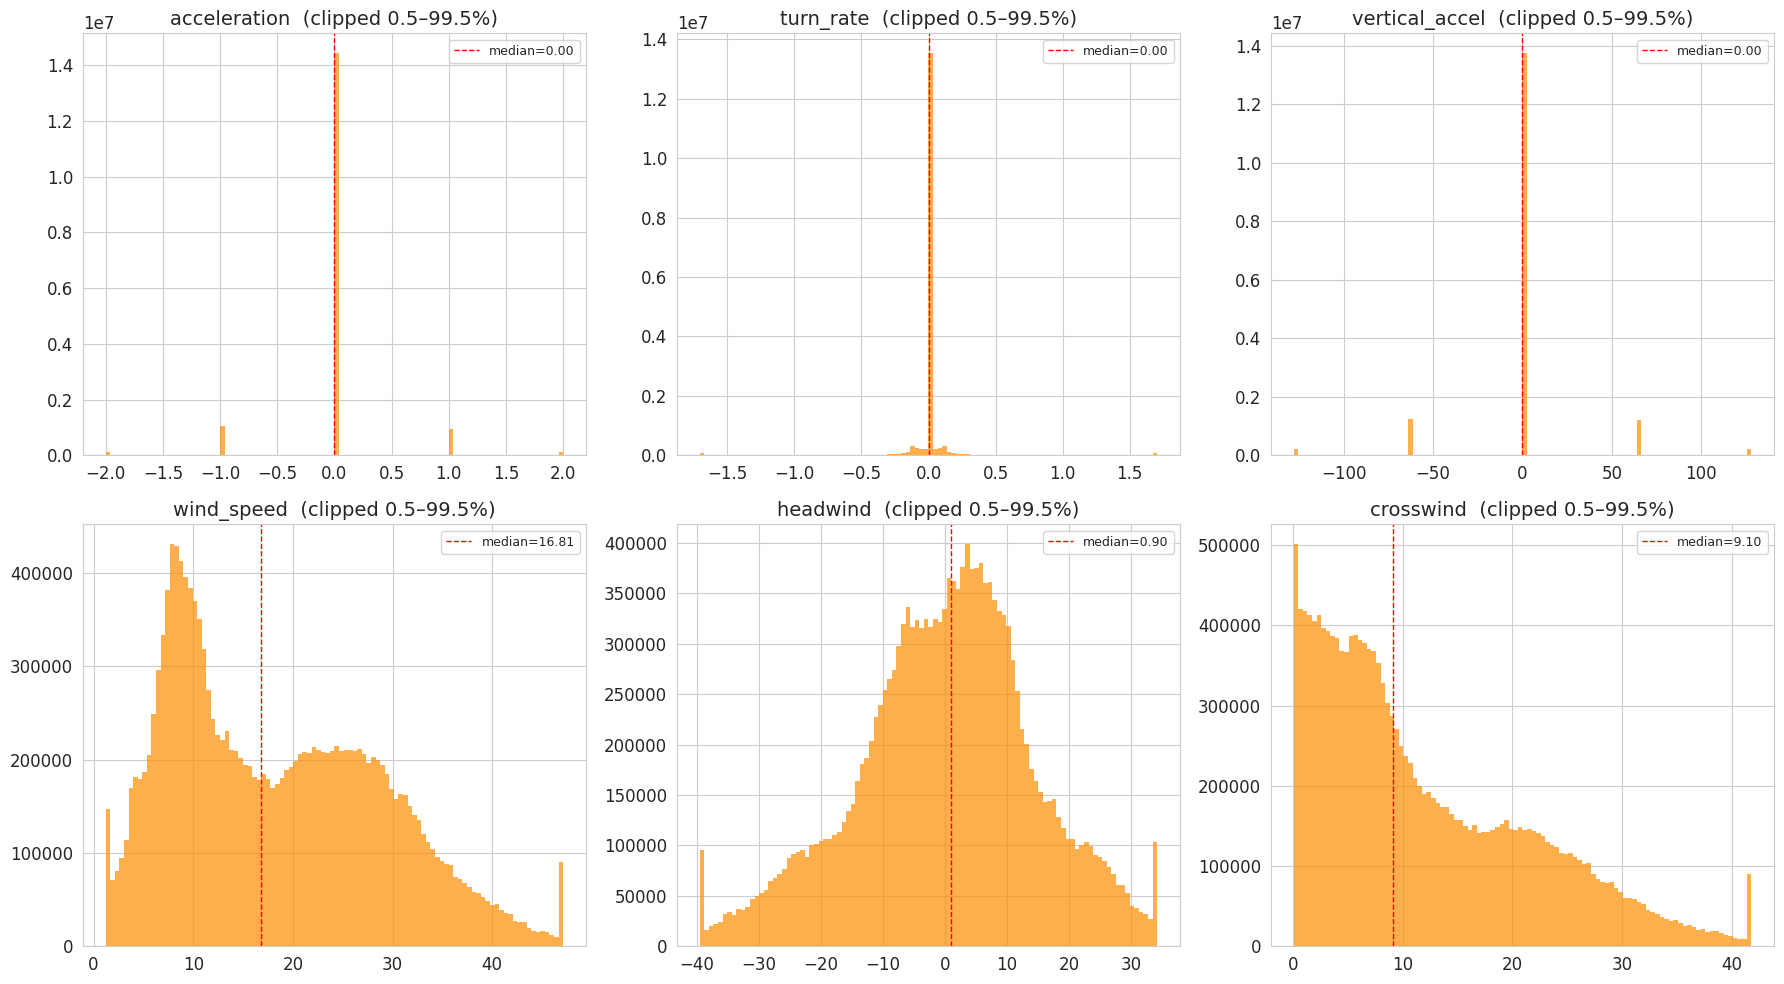

In [ ]:
derived_cols = ['acceleration', 'turn_rate', 'vertical_accel', 'wind_speed',
                'headwind', 'crosswind']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), derived_cols):
    data = df[col].dropna()
    lo, hi = data.quantile(0.005), data.quantile(0.995)
    ax.hist(data.clip(lo, hi), bins=100, edgecolor='none', alpha=0.7, color='darkorange')
    ax.set_title(f'{col}  (clipped 0.5–99.5%)')
    ax.axvline(data.median(), color='red', ls='--', lw=1, label=f'median={data.median():.2f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('derived_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Замечания по производным.

Верхний ряд, кинематические производные.

Все три распределения (acceleration, turn_rate, vertical_accel) имеют одинаковую структуру: узкий пик на нуле и почти пустые хвосты. Ожидаемо: большинство ADS-B точек приходится на крейсер, где самолёт летит прямо, горизонтально и с постоянной скоростью (acceleration ≈ 0, turn_rate ≈ 0, vertical_accel ≈ 0). Хвосты это фазы набора, снижения, маневрирования. В этих хвостах и скрываются аномалии.

Видна выраженная дискретность: отдельные столбцы на ±1 kts/s для acceleration и ±64 ft/min/s для vertical_accel. Следствие квантования ADS-B: groundspeed передаётся с шагом 1 kts, vertical_rate с шагом 64 ft/min. При dt = 1 с производная наследует этот шаг. Для моделей anomaly detection это не проблема: Isolation Forest и HDBSCAN устойчивы к дискретности, LSTM-autoencoder тоже при MSE loss. На этапе preprocessing дискретность частично снимается расширенным дифференцированием (окно 10 с вместо 1 с).

Нижний ряд, ветровые компоненты.

Wind speed. Бимодальное: приземный пик ~5-10 м/с и крейсерский ~20-30 м/с (jet stream на 200-300 гПа). Медиана 16.8 м/с, обычный ветер на 10-12 км. Структура следует за altitude: на высоте ветер сильнее.

Headwind. Симметричное вокруг нуля (медиана 0.9 м/с). Встречный и попутный примерно одинаково вероятны, что ожидаемо для разнонаправленного трафика над Европой. Хвосты до ±40 м/с, попутный/встречный jet stream.

Crosswind. Строго положительное (модуль), убывающее от пика ~2-5 м/с. Медиана 9.1 м/с. Значения >25 м/с (~50 kts) потенциально опасны для посадки, интересны для anomaly detection.

In [ ]:
# Экстремумы производных, прямые кандидаты на аномалии
print('Derived Feature Extremes')
for col in derived_cols:
    data = df[col].dropna()
    q = data.quantile([0.001, 0.01, 0.5, 0.99, 0.999])
    print(f'{col:>18s}:  P0.1={q.iloc[0]:>9.2f}  P1={q.iloc[1]:>9.2f}  '
          f'median={q.iloc[2]:>9.2f}  P99={q.iloc[3]:>9.2f}  P99.9={q.iloc[4]:>9.2f}')

=== Derived Feature Extremes ===
      acceleration:  P0.1=    -3.00  P1=    -1.00  median=     0.00  P99=     1.00  P99.9=     3.00
         turn_rate:  P0.1=    -3.12  P1=    -0.95  median=     0.00  P99=     0.98  P99.9=     3.18
    vertical_accel:  P0.1=  -256.00  P1=  -128.00  median=     0.00  P99=   128.00  P99.9=   256.00
        wind_speed:  P0.1=     0.48  P1=     1.81  median=    16.81  P99=    44.14  P99.9=    55.19
          headwind:  P0.1=   -46.86  P1=   -36.22  median=     0.90  P99=    31.89  P99.9=    40.11
         crosswind:  P0.1=     0.02  P1=     0.16  median=     9.10  P99=    38.76  P99.9=    48.48


Кинематические производные, видна дискретность квантования:
- acceleration: P99.9 = ±3 kts/s. При dt = 1 с это изменение скорости на 3 kts за секунду, интенсивное торможение или ускорение. Значения кратны 1.00, шаг квантования groundspeed (1 kts) при dt = 1 с.
- turn_rate: P99.9 = ±3.1 deg/s. Стандартный вираж (standard rate turn) = 3 deg/s. Значения за этим порогом - резкие манёвры или артефакты.
- vertical_accel: P99.9 = ±256 ft/min/s, P1/P99 = ±128. Кратно 64 (шаг квантования vertical_rate = 64 ft/min). Дискретность здесь максимальна из всех производных.

Все три распределения симметричны с медианой 0, крейсерский режим доминирует.

Ветровые компоненты:
- wind_speed P99.9 = 55 м/с (~107 kts), сильный jet stream. Реалистично для ноября над Атлантикой и Северной Европой.
- headwind P0.1 = −47 м/с (попутный), P99.9 = +40 м/с (встречный). Лёгкая асимметрия в сторону попутного ветра, согласуется с преобладающими westerlies и преобладанием восточного направления трафика.
- crosswind P99.9 = 48 м/с (~93 kts), экстремальные значения, скорее всего на крейсерских эшелонах при пересечении jet stream. При посадке crosswind >15 м/с уже ограничивающий фактор.

In [ ]:
# Дифференцирование через шаг N: (x[i+N] - x[i-N]) / (t[i+N] - t[i-N])
# Эквивалент сглаженной производной без rolling

N = 5  # шаг ±5, окно ~5 секунд при 1 Гц

df = df.sort_values(['flight_id', 'timestamp']).reset_index(drop=True)

fid = df['flight_id'].values
ts = df['timestamp'].values.astype('int64') / 1e9  # секунды

dt_wide = np.empty(len(df), dtype='float64')
dt_wide[:] = np.nan
dt_wide[N:-N] = ts[2*N:] - ts[:-2*N]

# Маска: обе точки должны быть из одного рейса
same_flight = np.ones(len(df), dtype=bool)
same_flight[:N] = False
same_flight[-N:] = False
for k in range(1, 2*N + 1):
    mask = np.empty(len(df), dtype=bool)
    mask[:] = False
    mask[k:] = fid[k:] == fid[:-k]
    same_flight &= mask

dt_wide[~same_flight] = np.nan

def wide_diff(col_values):
    d = np.empty(len(col_values), dtype='float64')
    d[:] = np.nan
    d[N:-N] = col_values[2*N:] - col_values[:-2*N]
    d[~same_flight] = np.nan
    return d / dt_wide

df['acceleration_smooth'] = wide_diff(df['groundspeed'].values)
df['vertical_accel_smooth'] = wide_diff(df['vertical_rate'].values)

# Track с wraparound
track_vals = df['track'].values
td = np.empty(len(track_vals), dtype='float64')
td[:] = np.nan
td[N:-N] = track_vals[2*N:] - track_vals[:-2*N]
td = ((td + 180) % 360) - 180
td[~same_flight] = np.nan
df['turn_rate_smooth'] = td / dt_wide

for col in ['acceleration_smooth', 'turn_rate_smooth', 'vertical_accel_smooth']:
    d = df[col].dropna()
    print(f'{col:>20s}: median={d.median():.2f}, std={d.std():.2f}, '
          f'P1={d.quantile(0.01):.2f}, P99={d.quantile(0.99):.2f}')

           acceleration_smooth: median=0.0000, std=0.4135, P1=-0.8000, P99=1.1000
              turn_rate_smooth: median=0.0000, std=0.2988, P1=-1.0266, P99=1.0628
         vertical_accel_smooth: median=0.0000, std=23.7440, P1=-76.8000, P99=76.8000


### Расширенное дифференцирование (wide differencing)

Обычные конечные разности (dt = 1 с) дают сильную дискретность из-за квантования ADS-B. Альтернатива - расширенное дифференцирование: вместо (x[i] − x[i−1]) / 1с берём (x[i+5] − x[i−5]) / 10с. Окно 10 секунд сглаживает квантовый шум и не требует промежуточных структур (rolling mean), экономит RAM на 16.7M строках.

Маска `same_flight` гарантирует, что дифференцирование не пересекает границы рейсов: точки на стыке двух рейсов получают NaN.

Сравнение с обычными производными:

| Признак | Обычная (1 с) P99 | Сглаженная (10 с) P99 | Эффект |
|---|---|---|---|
| acceleration | ±1.00 kts/s | ±0.8–1.1 kts/s | хвосты сузились, дискретные пики размыты |
| turn_rate | ±0.98 deg/s | ±1.03 deg/s | почти без изменений, turn rate менее дискретен |
| vertical_accel | ±128 ft/min/s | ±76.8 ft/min/s | было кратно 64, стало кратно ~12.8, дискретность снижена в ~5 раз |

Берём расширенное дифференцирование как основной метод для preprocessing. Обычные конечные разности в финальный пайплайн не попадают.

## 6. Пространственный анализ

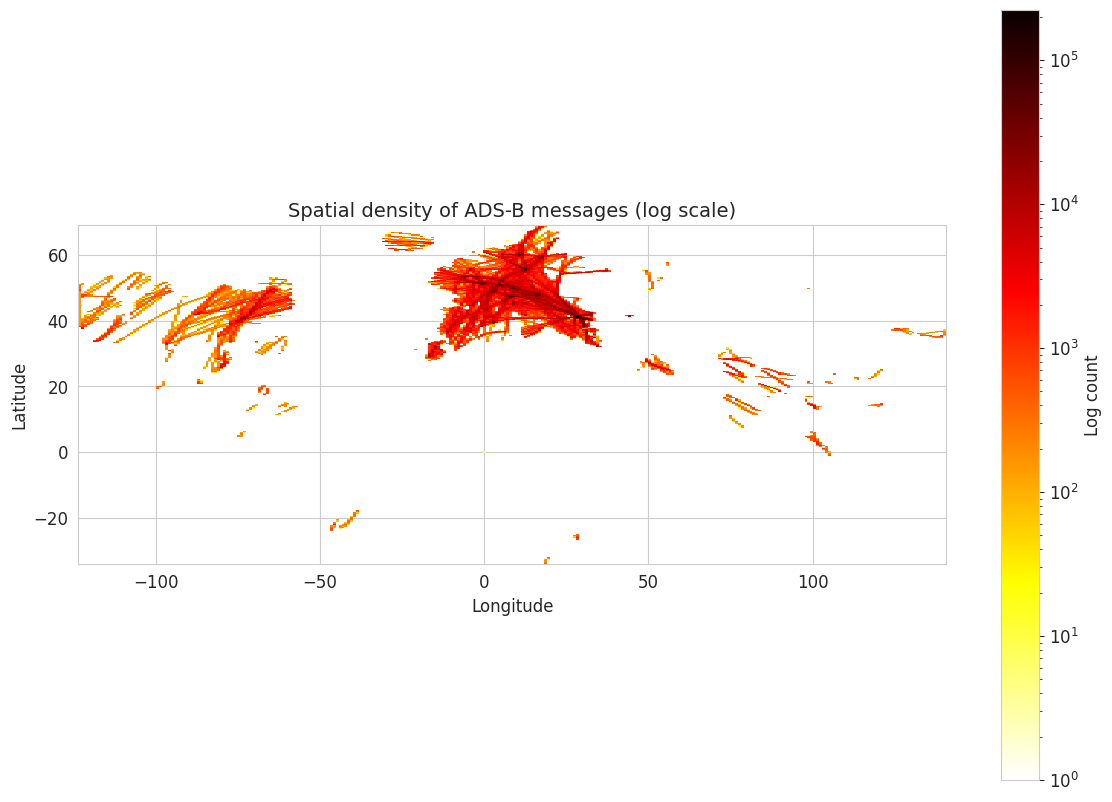

In [ ]:
# 2D-гистограмма lat/lon, пространственная плотность
fig, ax = plt.subplots(figsize=(14, 10))
h = ax.hist2d(df['longitude'], df['latitude'],
              bins=[300, 300], cmap='hot_r',
              norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(h[3], ax=ax, label='Log count')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial density of ADS-B messages (log scale)')
ax.set_aspect('equal')
plt.savefig('spatial_density.png', dpi=150, bbox_inches='tight')
plt.show()

Тепловая карта пространственной плотности ADS-B сообщений (логарифмическая шкала) показывает три зоны.

Плотное ядро над Европой (lon −15°…40°, lat 35°…65°). Максимальная концентрация (10⁴-10⁵ сообщений на бин) над Центральной Европой: Франция, Германия, страны Бенилюкса, Северная Италия. Видны очертания воздушных коридоров и хабов. Покрытие наземными приёмниками здесь плотное, данные непрерывные.

Трансатлантические трассы (lon −100°…−50°, lat 35°…55°). Отчётливые линии рейсов между Европой и восточным побережьем США/Канады. Плотность на 2-3 порядка ниже (10¹-10²), покрытие разреженное (океан, минимум приёмников), данные фрагментарны.

Юго-Восточная Азия и Ближний Восток (lon 50°…130°, lat 5°…40°). Единичные дальнемагистральные рейсы из Европы. Плотность минимальна (10⁰-10¹).

Это подтверждает решение ограничить анализ европейским bbox (lat 35-72°, lon −15-40°): за его пределами покрытие слишком разреженное для надёжного обнаружения аномалий. Внутри Европы плотность достаточна.

Взглянем на 100 самых длинных полётов.

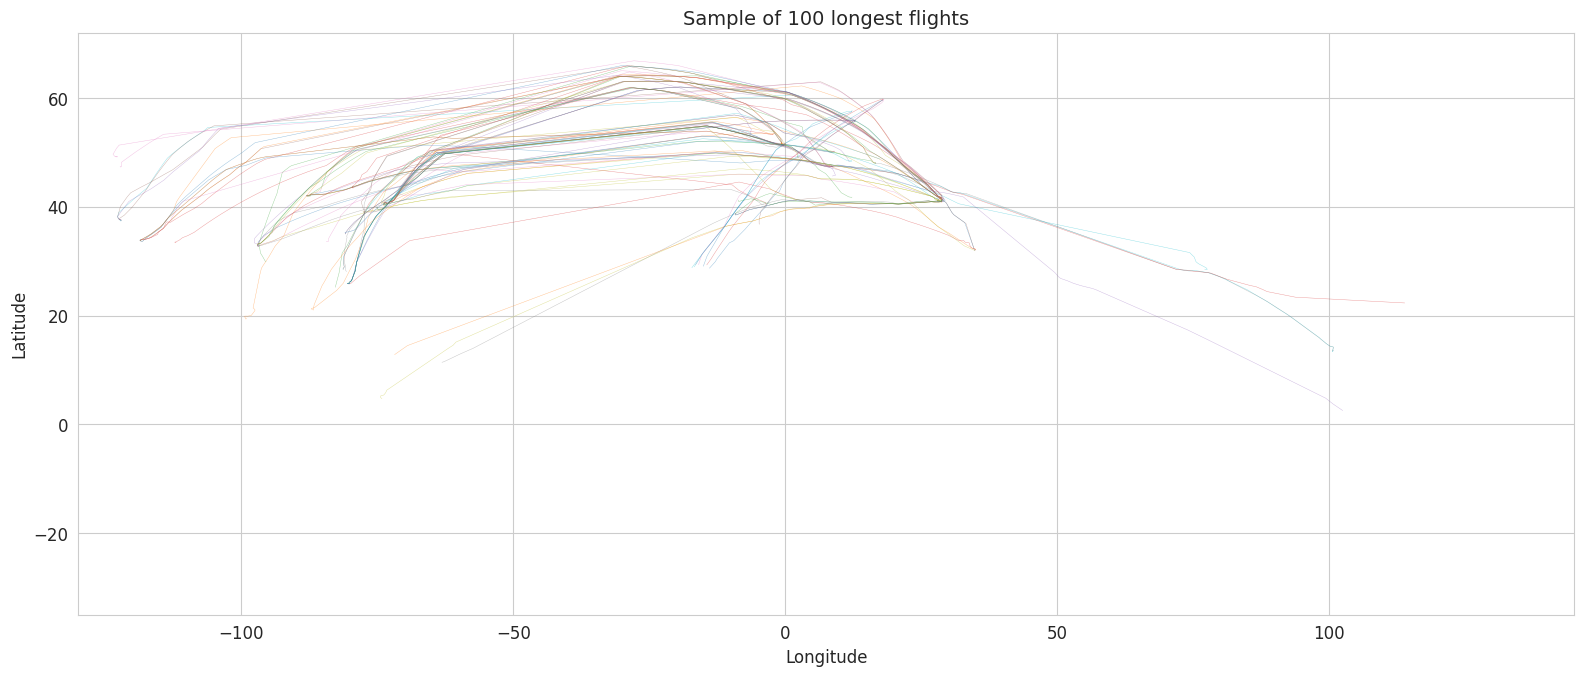

In [ ]:
fig, ax = plt.subplots(figsize=(16, 10))

sample_ids = df.groupby('flight_id').size().nlargest(100).index
for fid in sample_ids:
    fdata = df.loc[df['flight_id'] == fid, ['longitude', 'latitude']]
    ax.plot(fdata['longitude'], fdata['latitude'], lw=0.3, alpha=0.5)

ax.set_xlim(-130, 145)
ax.set_ylim(-35, 72)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Sample of 100 longest flights')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('flight_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

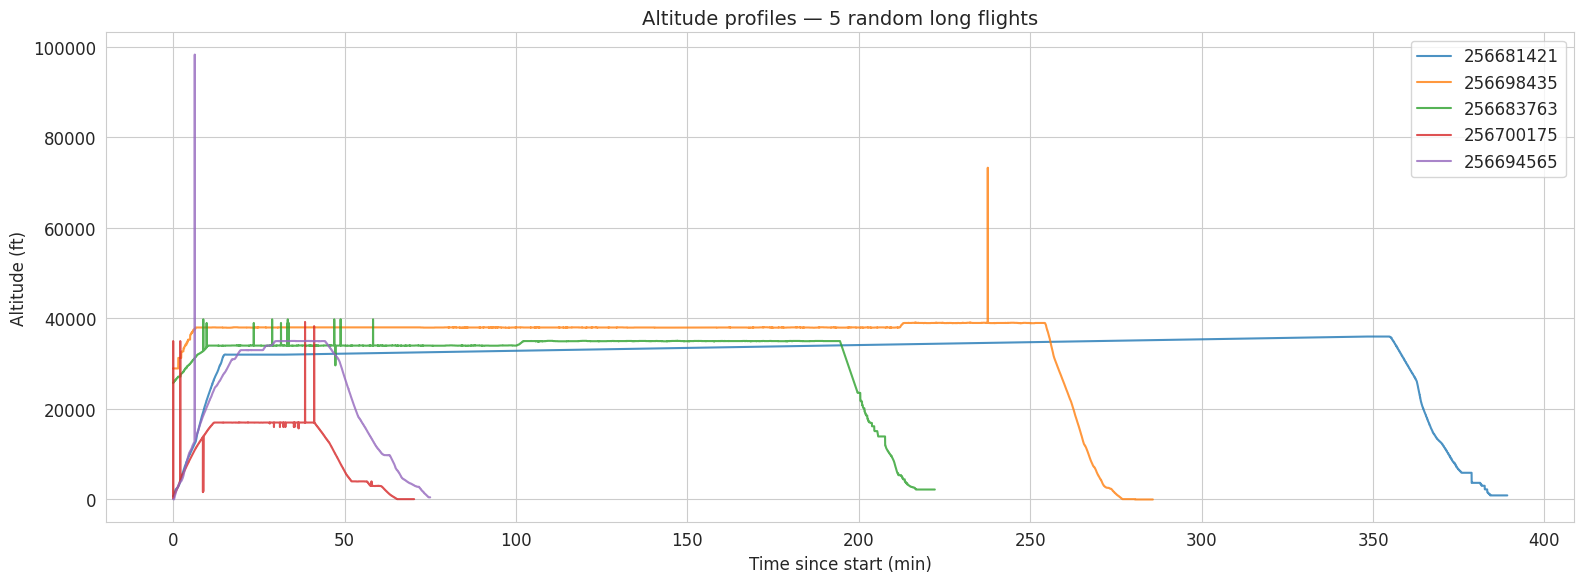

In [ ]:
# Высотный профиль случайной выборки рейсов
flight_sizes = df.groupby('flight_id').agg(
    n_points=('timestamp', 'size'),
    duration_s=('timestamp', lambda x: (x.max() - x.min()).total_seconds())
)
sample_ids_5 = flight_sizes[
    (flight_sizes['duration_s'] > 3600) & (flight_sizes['n_points'] > 200)
].sample(5, random_state=1321).index

fig, ax = plt.subplots(figsize=(16, 6))
for fid in sample_ids_5:
    fdata = df[df['flight_id'] == fid].sort_values('timestamp')
    t_min = (fdata['timestamp'] - fdata['timestamp'].min()).dt.total_seconds() / 60
    ax.plot(t_min, fdata['altitude'], label=str(fid)[:12], alpha=0.8)

ax.set_xlabel('Time since start (min)')
ax.set_ylabel('Altitude (ft)')
ax.set_title('Altitude profiles, 5 random long flights')
ax.legend()
plt.tight_layout()
plt.savefig('altitude_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

Высотные профили 5 случайных длинных рейсов наглядно показывают и типичные паттерны, и проблемы данных.

Типичные профили. Рейсы 256681421 (синий) и 256683763 (зелёный) - классическая трапеция: набор, крейсер, снижение. Крейсер на 34 000-39 000 ft, длительность 200-400 мин. У синего видна ступенчатая посадка (step-down approach), снижение по командам ATC на дискретные эшелоны.

Артефакты ADS-B, два выброса:
- Фиолетовый рейс (256694565), спайк до ~98 000 ft в начале записи. Бит-флип при декодировании: реальная высота ~34 000 ft, ошибочный бит превращает её в ~98 000 ft. Единичная точка, не влияет на траекторию.
- Оранжевый рейс (256698435), спайк до ~73 000 ft на ~210 мин, тот же механизм.

Оба артефакта - кандидаты для медианного фильтра: одиночные выбросы на фоне стабильного сигнала корректируются окном 7 точек.

Неполные траектории. Красный рейс (256700175) начинается на ~15 000 ft и заканчивается снижением к ~3 000 ft, запись начата в середине полёта (самолёт вошёл в зону покрытия ADS-B уже на эшелоне). Фиолетовый обрывается после нескольких фрагментов, возможны пропуски покрытия. Подтверждает наличие неполных рейсов, выявленное при анализе alt_range.

## 7. Временные паттерны

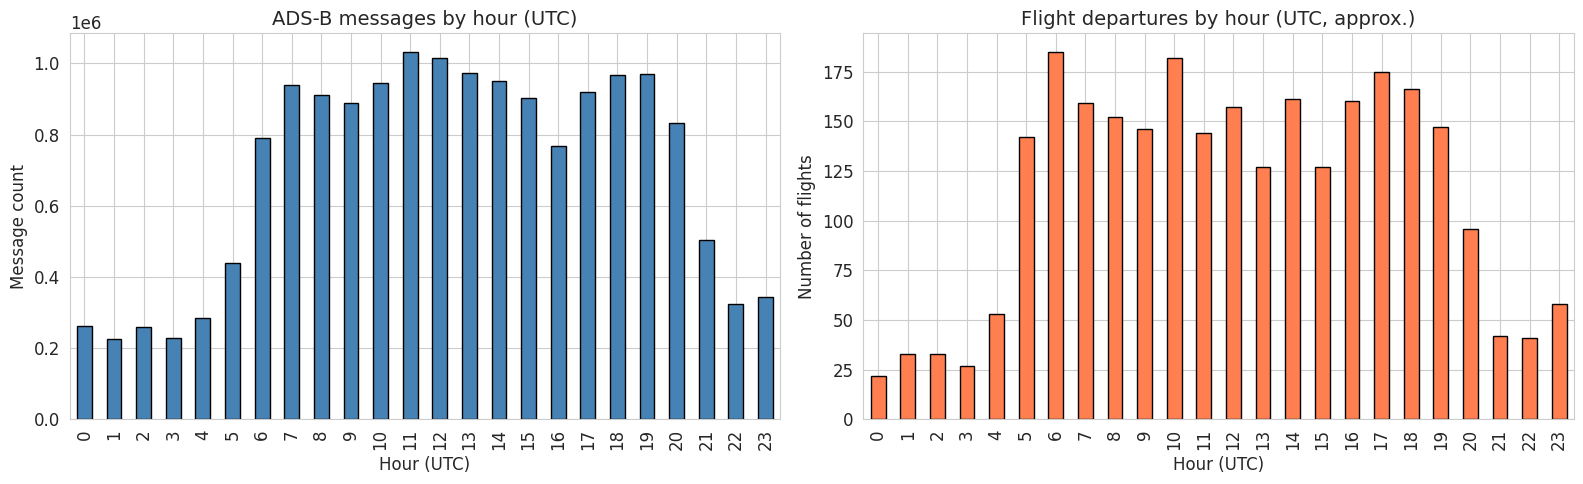

In [ ]:
# Сообщения по часам суток
df['hour'] = df['timestamp'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Сообщения за час
df.groupby('hour').size().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('ADS-B messages by hour (UTC)')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Message count')

# Уникальные рейсы за час (первое сообщение)
flights_by_hour = (
    df.sort_values('timestamp')
    .groupby('flight_id')['hour']
    .first()
    .value_counts()
    .sort_index()
)
flights_by_hour.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Flight departures by hour (UTC, approx.)')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Number of flights')

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

ADS-B messages by hour (левый график) - количество сообщений в воздухе в каждый час. Чёткий суточный паттерн: минимум в 01-04 UTC (~220-230 тыс.), плавный рост с 05 UTC, плато на ~900 тыс. - 1 млн с 07 до 20 UTC, спад к ночи. Два лёгких провала на 15-17 UTC и 21 UTC, возможно, связаны с волнами трафика между утренним и вечерним пиком. Ночной минимум не опускается до нуля: дальнемагистральные и cargo летят круглосуточно.

Flight departures by hour (правый график) - рейсы, начавшие запись в каждый час (приближённое время вылета). Структура отличается от сообщений: резкий пик в 06 UTC (~185 рейсов), утренняя волна вылетов из европейских хабов. Затем относительно ровное плато 120-170 рейсов/час с 07 до 18 UTC. Второй, менее выраженный пик в 17-18 UTC - вечерняя волна. Резкий спад после 19 UTC.

Утренний пик вылетов в 06 UTC совпадает с началом роста общего трафика (левый график) - волна короткомагистральных рейсов, стартующая одновременно. Для anomaly detection: утренние и вечерние часы содержат больше фаз набора и снижения, дневное плато - больше крейсерских точек.

Временной шаг (выборка 1000 рейсов):
  медиана = 1.0 с, среднее = 1.4 с, P5 = 1.0 с, P95 = 1.0 с


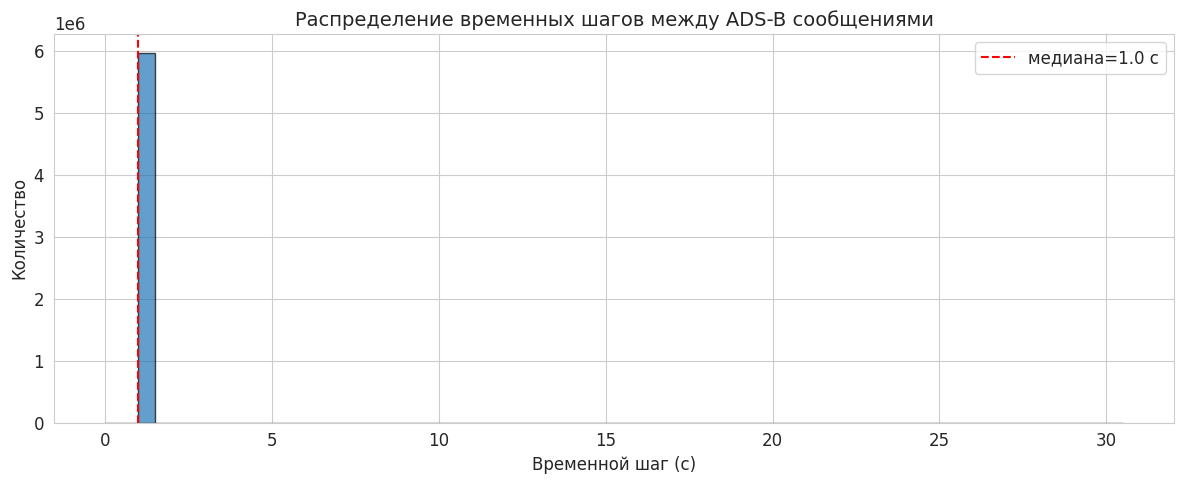

In [ ]:
# Распределение временных шагов между ADS-B сообщениями
sample_flights = df['flight_id'].drop_duplicates().sample(
    min(1000, df['flight_id'].nunique()), random_state=1321
)
dts = (
    df[df['flight_id'].isin(sample_flights)]
    .sort_values(['flight_id', 'timestamp'])
    .groupby('flight_id')['timestamp']
    .diff()
    .dt.total_seconds()
    .dropna()
)

print(f'Временной шаг (выборка 1000 рейсов):')
print(f'  медиана = {dts.median():.1f} с, среднее = {dts.mean():.1f} с, '
      f'P5 = {dts.quantile(0.05):.1f} с, P95 = {dts.quantile(0.95):.1f} с')

fig, ax = plt.subplots(figsize=(12, 5))
dts_clipped = dts[dts.between(0, 30)]
ax.hist(dts_clipped, bins=np.arange(0, 31, 0.5), edgecolor='black', alpha=0.7)
ax.set_xlabel('Временной шаг (с)')
ax.set_ylabel('Количество')
ax.set_title('Распределение временных шагов между ADS-B сообщениями')
ax.axvline(dts.median(), color='red', ls='--', label=f'медиана={dts.median():.1f} с')
ax.legend()
plt.tight_layout()
plt.show()

Подавляющее большинство временных шагов между ADS-B сообщениями равно ровно 1 секунде, частота 1 Гц. Медиана = 1.0 с, P5 = 1.0 с, P95 = 1.0 с, данные практически идеально регулярные.

Шаги >1 с настолько редки, что на графике не видны (масштаб оси Y в миллионах, пропуски единичны). Ресемплирование или интерполяция временных рядов не требуются: данные уже равномерно дискретизированы. Для расчёта производных безопасно предполагать dt = 1 с в подавляющем большинстве случаев, но в коде dt вычисляется явно для корректности на редких пропусках.

## 8. Метеопризнаки

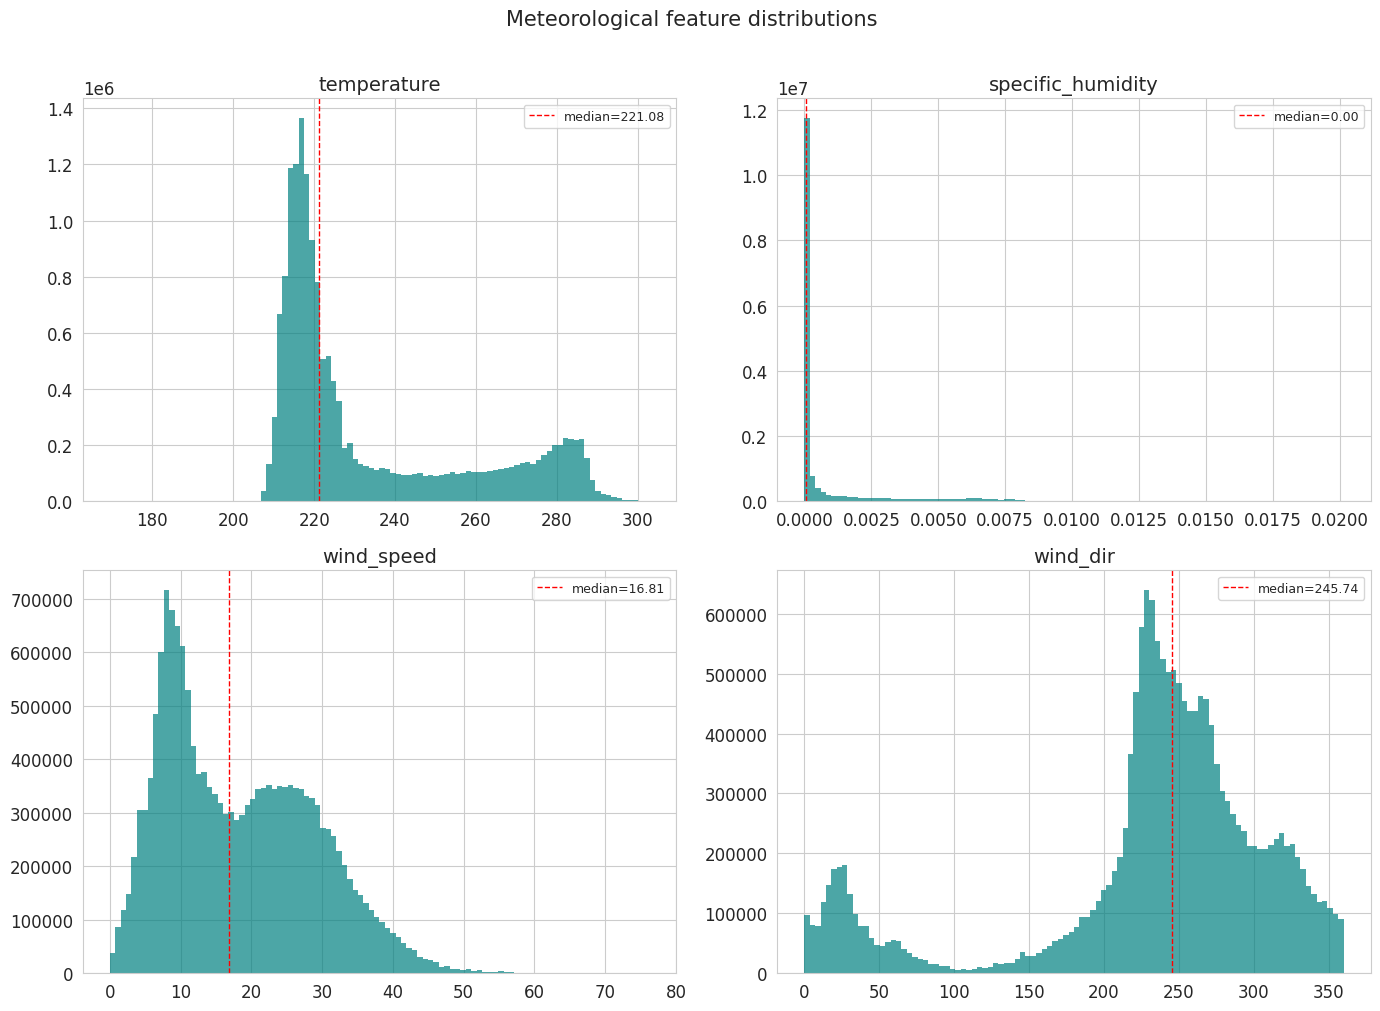

In [ ]:
meteo_cols = ['temperature', 'specific_humidity', 'wind_speed', 'wind_dir']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), meteo_cols):
    data = df[col].dropna()
    ax.hist(data, bins=100, edgecolor='none', alpha=0.7, color='teal')
    ax.set_title(col)
    ax.axvline(data.median(), color='red', ls='--', lw=1, label=f'median={data.median():.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Meteorological feature distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('meteo_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Temperature. Бимодальное распределение, отражает структуру атмосферы. Острый пик на ~218-222 K (−55…−51°C), температура тропопаузы на крейсерских эшелонах (30 000-40 000 ft), где самолёт проводит большую часть времени. Второй, более широкий пик на ~280-290 K (+7…+17°C), приземная температура в ноябре в Европе. Провал между ними - зона набора и снижения. Бимодальность повторяет структуру altitude, что предсказывает сильную корреляцию (в EDA подтвердится: r = −0.98). Поэтому temperature исключим из модельного набора: дублирует altitude.

Specific humidity. Подавляющее большинство значений ≈ 0 (медиана = 0.00). Стратосфера и верхняя тропосфера почти сухие. Ненулевые значения (до 0.02 кг/кг) соответствуют приземным фазам. Распределение сильно скошено вправо, информативность минимальна, признак исключаем (r = −0.83 с altitude).

Wind speed. Бимодальное: приземный пик ~5-10 м/с (пограничный слой) и крейсерский ~25-35 м/с (jet stream на высотах 200-300 гПа). Медиана 16.8 м/с. Хвост до 70+ м/с, мощный jet stream над Северной Атлантикой в ноябре. В отличие от temperature, wind_speed несёт дополнительную информацию: корреляция с altitude умеренная (r = 0.42), признак сохраняем.

Wind direction. Выраженное преобладание юго-западных ветров (пик на 220-280°, медиана 246°). Это westerlies, преобладающие западные ветры средних широт, усиленные в ноябре. Вторичный пик на ~30-50° (северо-восточный ветер), вероятно приземные потоки в отдельных регионах. Согласуется с климатологией Европы для данного периода.

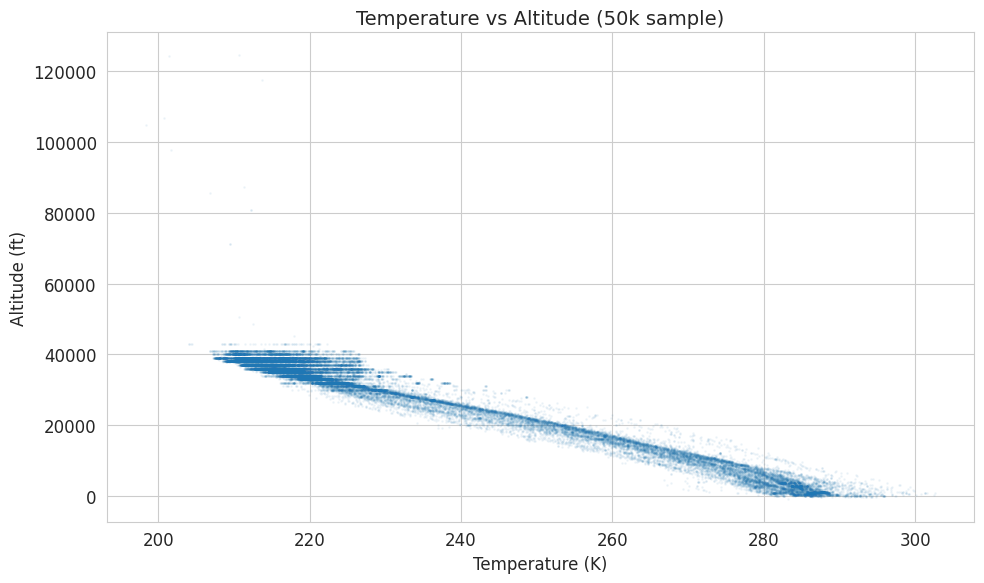

In [ ]:
# Температура vs высота, должна примерно следовать стандартной атмосфере
sample = df[['altitude', 'temperature']].dropna().sample(50000, random_state=1321)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample['temperature'], sample['altitude'], alpha=0.05, s=1)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Altitude (ft)')
ax.set_title('Temperature vs Altitude (50k sample)')
plt.tight_layout()
plt.savefig('temp_vs_altitude.png', dpi=150, bbox_inches='tight')
plt.show()

Scatter plot подтверждает почти линейную зависимость температуры от высоты, стандартный атмосферный градиент. От земли (примерно 290 K, 0 ft) до тропопаузы (~220 K, 36 000 ft) температура падает с градиентом ~6.5 K/км, соответствует модели ISA (International Standard Atmosphere).

Выше ~36 000 ft видно выполаживание, изотермия стратосферы: температура перестаёт падать и остаётся ~210-220 K. Граница тропопаузы видна на графике как горизонтальное скопление точек.

Разброс по горизонтали на одной высоте (±5-10 K) - реальная пространственная вариативность: температура зависит от широты, времени суток и синоптической ситуации. Над Скандинавией на 35 000 ft холоднее, чем над Средиземноморьем.

Дискретные горизонтальные полосы на крейсерских высотах (35 000, 37 000, 39 000 ft) - эшелоны: самолёты летят на фиксированных FL, точки концентрируются на дискретных высотах.

Вывод. Зависимость практически детерминированная (r = −0.98). Temperature не несёт информации сверх altitude, оба признака вместе создадут мультиколлинеарность без добавления сигнала. Temperature исключаем.

## 9. Корреляции

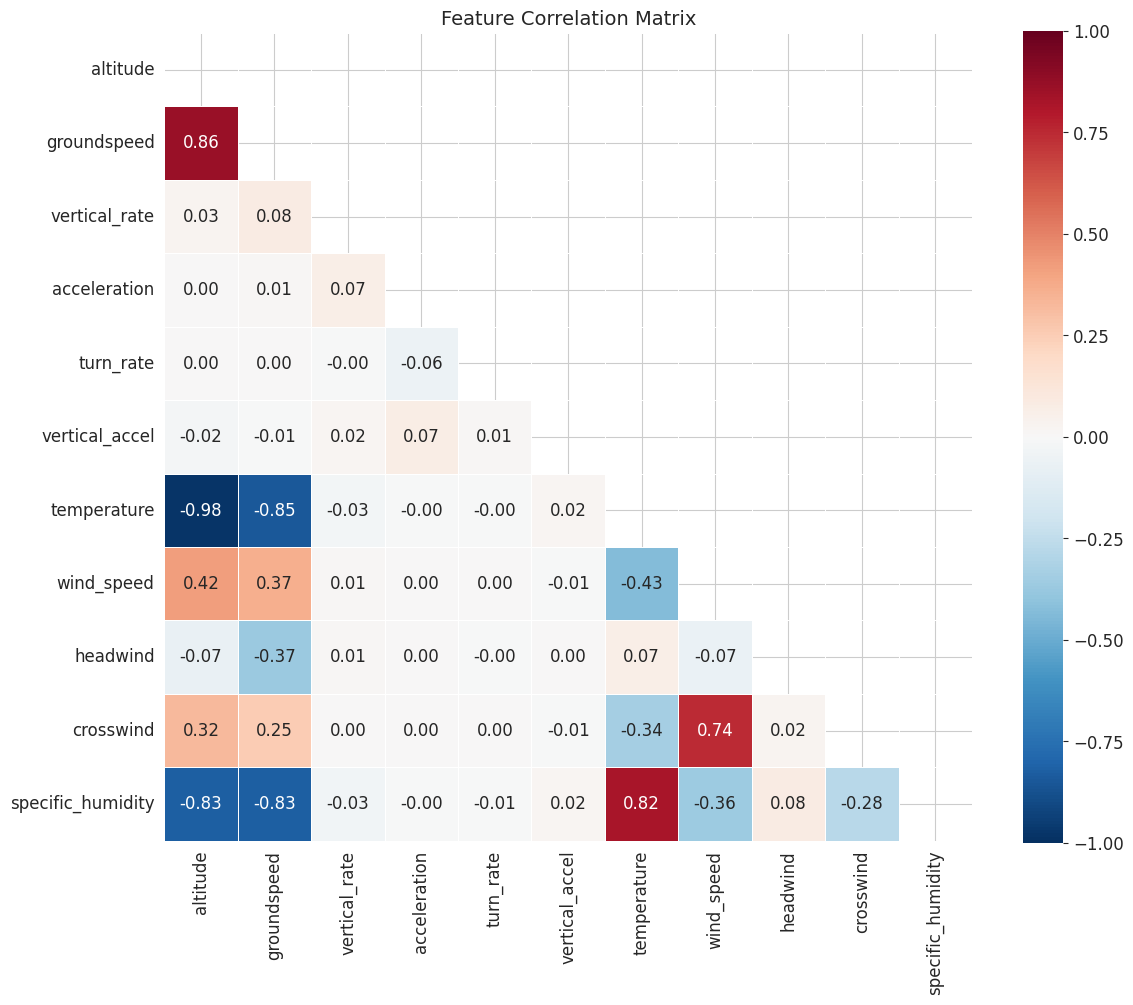

In [ ]:
corr_cols = ['altitude', 'groundspeed', 'vertical_rate', 'acceleration',
             'turn_rate', 'vertical_accel', 'temperature', 'wind_speed',
             'headwind', 'crosswind', 'specific_humidity']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Корреляционная матрица выявляет три группы признаков с разной структурой зависимостей.

Высотный кластер, сильные корреляции, обусловленные физикой атмосферы:
- altitude и groundspeed (r = 0.86): на большей высоте самолёт летит быстрее (разрежённый воздух, меньшее сопротивление);
- altitude и temperature (r = −0.98): стандартный атмосферный градиент, почти детерминированная связь;
- altitude и specific_humidity (r = −0.83): стратосфера сухая;
- crosswind и wind_speed (r = 0.74): сильный ветер на крейсере создаёт большую боковую компоненту.

Temperature и specific_humidity полностью дублируют altitude, исключаем из модели.

Динамический кластер, нулевые корреляции со всем:
- acceleration, turn_rate, vertical_accel - все три имеют |r| < 0.07 с любым другим признаком. Независимые сигналы о мгновенной динамике полёта. Несут уникальную информацию для обнаружения аномалий: резкий манёвр не коррелирует с высотой, скоростью или погодой.

Ветровой кластер, умеренные связи:
- wind_speed и altitude (r = 0.42): jet stream на высоте, штиль у земли;
- headwind и groundspeed (r = −0.37): встречный ветер снижает путевую скорость, физически ожидаемо;
- headwind слабо связан с остальными (|r| ≤ 0.07), несёт самостоятельную информацию о ветровых условиях.

Главное для моделирования: динамический кластер (acceleration, turn_rate, vertical_accel) - основные кандидаты для anomaly detection, ортогональны ко всем остальным признакам. Аномалия в ускорении не объясняется высотой, скоростью или погодой, ровно то, что хотим детектировать.

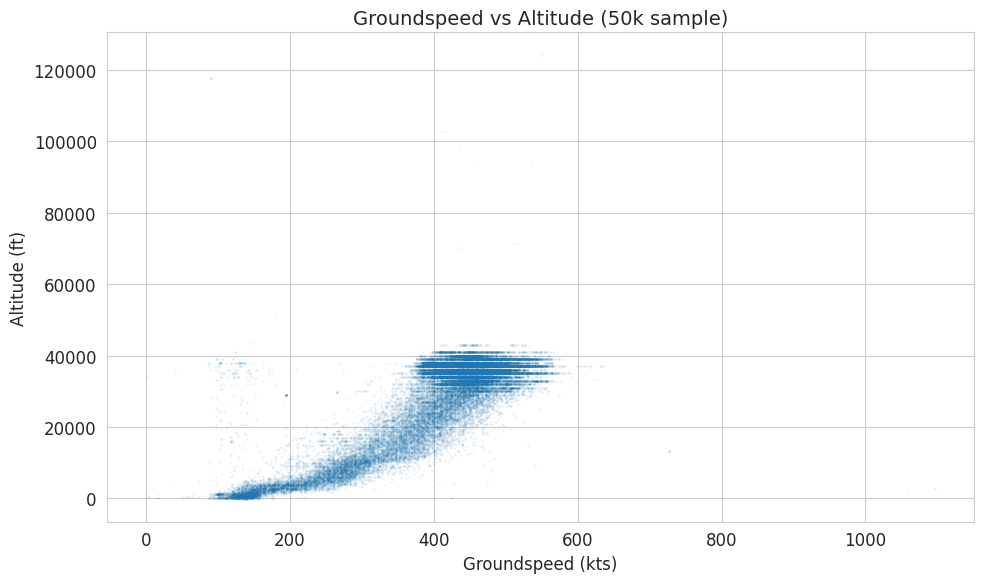

In [ ]:
# Groundspeed vs altitude, должна показать ожидаемый паттерн
sample2 = df[['altitude', 'groundspeed']].dropna().sample(50000, random_state=1321)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample2['groundspeed'], sample2['altitude'], alpha=0.05, s=1)
ax.set_xlabel('Groundspeed (kts)')
ax.set_ylabel('Altitude (ft)')
ax.set_title('Groundspeed vs Altitude (50k sample)')
plt.tight_layout()
plt.savefig('gs_vs_altitude.png', dpi=150, bbox_inches='tight')
plt.show()

Scatter plot groundspeed vs altitude показывает характерную веерную структуру с двумя режимами.

Приземный кластер (0-5 000 ft, 0-200 kts). Руление, взлёт, заход на посадку. Скорости низкие, ограничены аэродинамикой и правилами (ограничения до 250 kts ниже 10 000 ft в воздушном пространстве EUROCONTROL). Плотное облако в левом нижнем углу: самолёт на земле (GS ≈ 0-30 kts) или на короткой посадочной прямой.

Крейсерский кластер (30 000-40 000 ft, 380-520 kts). Основная масса точек. Видны дискретные горизонтальные полосы, фиксированные эшелоны (FL350, FL370, FL390). Разброс по GS на одном эшелоне (~100 kts) объясняется разницей в типах ВС (турбопропы vs тяжёлые wide-body) и влиянием ветра (попутный jet stream добавляет до 100 kts к путевой скорости).

Зона набора/снижения (5 000-30 000 ft, 200-400 kts). Переходная область с меньшей плотностью: самолёт проходит эти высоты быстро.

Артефакты, изолированные точки:
- altitude ~120 000 ft при GS ~150 kts, бит-флип высоты (уже замечен ранее);
- GS > 600 kts при низкой или средней высоте, артефактные скорости, физически невозможные для дозвуковых ВС в плотной атмосфере.

Форма облака подтверждает корреляцию r = 0.86: выше = быстрее, но зависимость нелинейная, на крейсере рост скорости с высотой замедляется из-за ограничений числа Маха.

## 10. Предварительный поиск выбросов

Перед обучением моделей пометим очевидные выбросы простыми статистическими правилами. Это даёт baseline и помогает потом валидировать anomaly-детекторы.

In [ ]:
# Z-score флаги выбросов по производным
outlier_cols = ['acceleration', 'turn_rate', 'vertical_accel']

outlier_flags = pd.DataFrame(index=df.index)
for col in outlier_cols:
    data = df[col].dropna()
    mu, sigma = data.mean(), data.std()
    # точки за 4 сигма
    outlier_flags[f'{col}_outlier'] = (df[col] - mu).abs() > 4 * sigma

outlier_flags['any_outlier'] = outlier_flags.any(axis=1)

print('Outlier Summary (|z| > 4)')
for col in outlier_flags.columns:
    n = outlier_flags[col].sum()
    print(f'  {col:>20s}: {n:,d} points ({n/len(df)*100:.3f}%)')

=== Outlier Summary (|z| > 4) ===
       acceleration_outlier:   11,115 points (0.067%)
          turn_rate_outlier:   68,701 points (0.412%)
     vertical_accel_outlier:   53,492 points (0.321%)
                any_outlier:  122,387 points (0.734%)


Простой Z-score фильтр (|z| > 4σ) на трёх динамических признаках даёт базовую оценку доли аномальных точек.

- turn_rate - лидер: 68 701 точка (0.41%). Развороты, holding patterns, vectoring от ATC, всё это создаёт turn_rate, выходящий за 4σ. Порог 4σ ≈ ±1.4 deg/s, ниже стандартного rate turn (3 deg/s), фильтр ловит даже умеренные манёвры.
- vertical_accel - 53 492 точки (0.32%). Резкие переходы между набором и горизонтальным полётом, выравнивание на эшелоне, turbulence-induced толчки.
- acceleration - наименьший: 11 115 точек (0.07%). Groundspeed меняется плавнее, чем курс или вертикальная скорость, ускорения и торможения инерционнее.

Суммарно 122 387 точек (0.73%) помечены хотя бы по одному признаку. Это верхняя оценка: большая часть приходится на штатные манёвры (заход, разворот), а не на аномалии. Z-score не различает интенсивный, но нормальный манёвр и реальную аномалию. Для этого нужны контекстные методы (Isolation Forest, HDBSCAN, LSTM-AE), учитывающие фазу полёта и временную последовательность.

In [ ]:
# Рейсы с наибольшим числом выбросов, кандидаты для детального осмотра
df['any_outlier'] = outlier_flags['any_outlier']
outlier_by_flight = (
    df.groupby('flight_id')['any_outlier']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'n_outlier', 'count': 'n_total'})
)
outlier_by_flight['outlier_pct'] = (outlier_by_flight['n_outlier'] /
                                     outlier_by_flight['n_total'] * 100).round(1)

top_outlier_flights = outlier_by_flight.nlargest(20, 'n_outlier')
print('Top 20 Flights by Outlier Count')
print(top_outlier_flights)

=== Top 20 Flights by Outlier Count ===
           n_outlier  n_total  outlier_pct
flight_id                                 
256681420        315     6504          4.8
256681390        293    11084          2.6
256681578        288     5061          5.7
256681630        261     4703          5.5
256681704        255     4031          6.3
256681369        224     6019          3.7
256681989        205     4559          4.5
256682644        194     4375          4.4
256681751        190     3832          5.0
256682155        188    12389          1.5
256700351        179     3713          4.8
256691671        174     5320          3.3
256681386        172    17645          1.0
256698814        168     5845          2.9
256682230        166     6916          2.4
256685155        164    14613          1.1
256681509        155    12797          1.2
256687067        151     4731          3.2
256681561        146     3650          4.0
256689204        144     4138          3.5


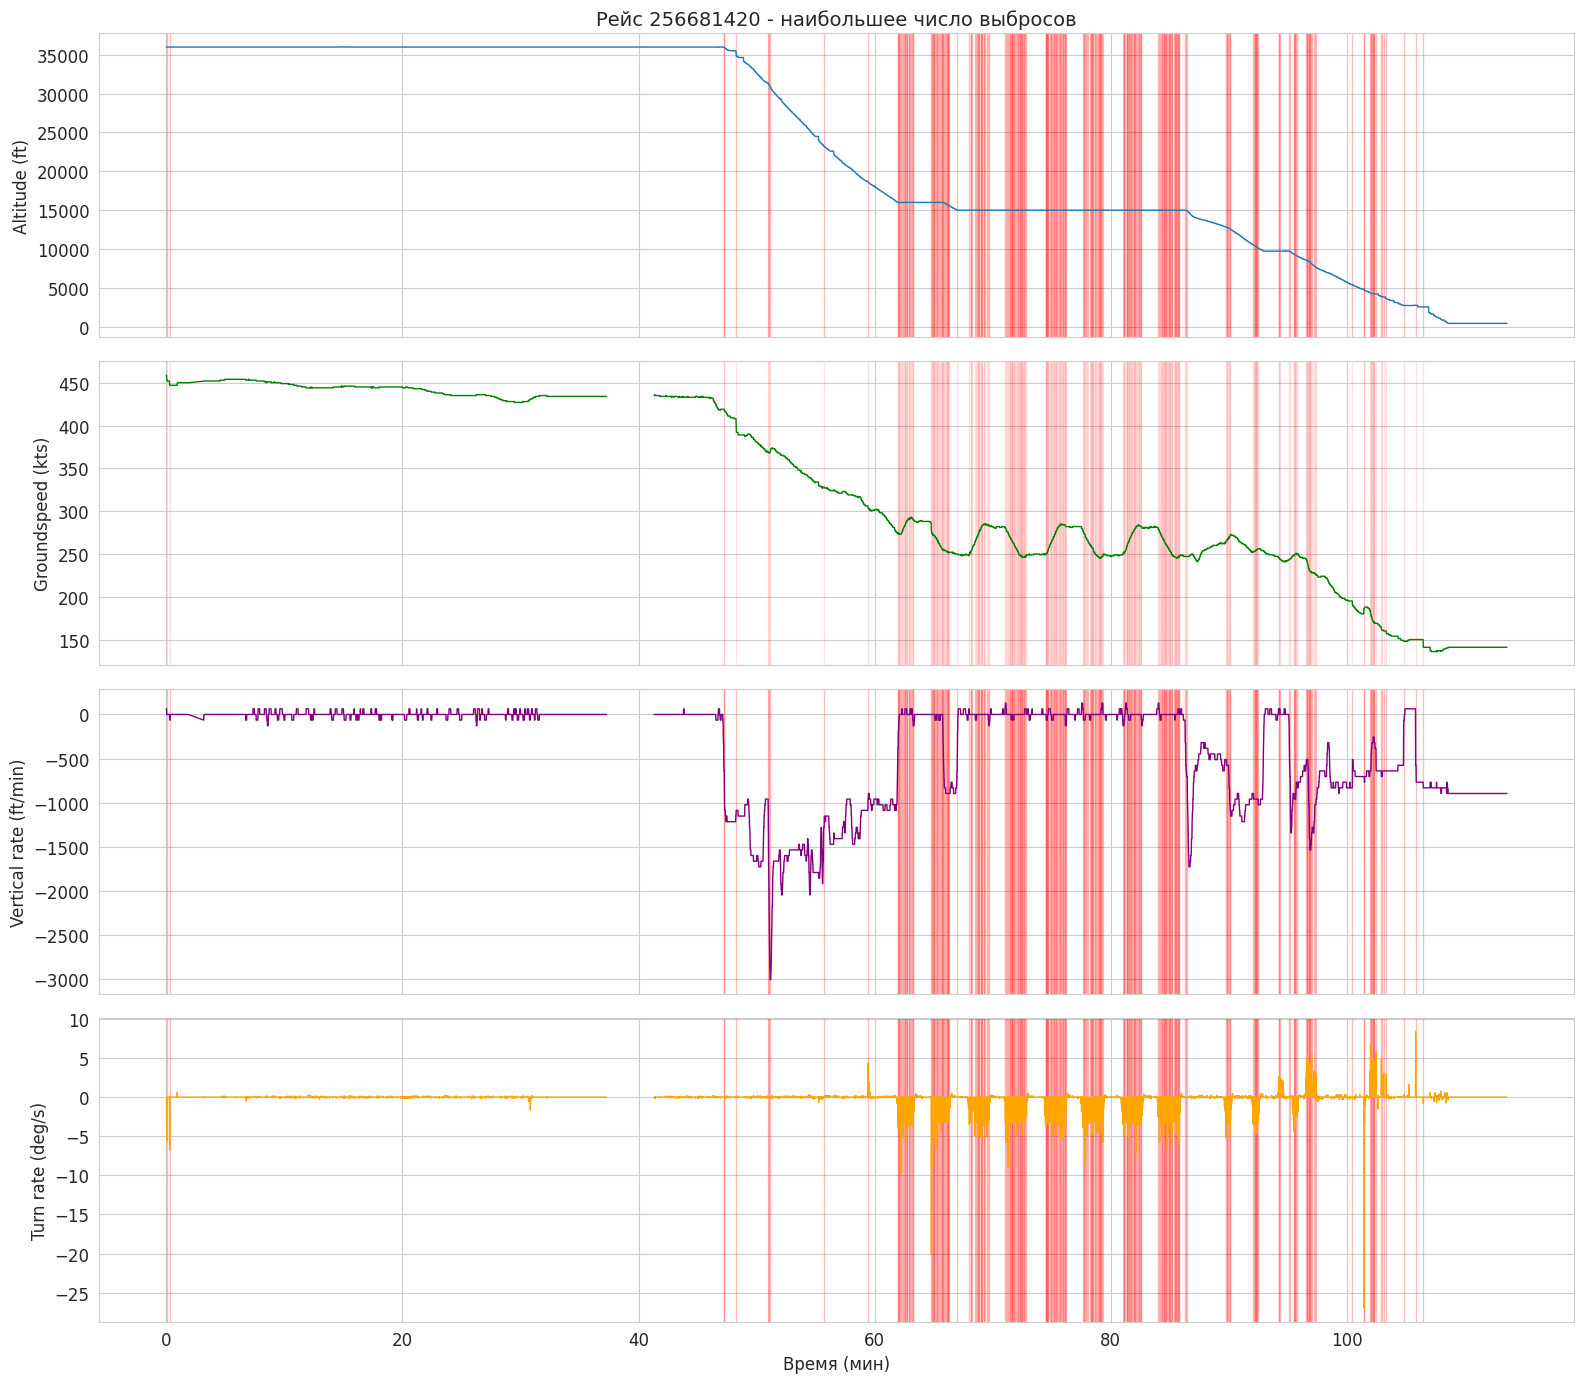

In [ ]:
# Визуализация рейса с наибольшим числом выбросов
worst_fid = top_outlier_flights.index[0]
fdata = df[df['flight_id'] == worst_fid].sort_values('timestamp').copy()
t_min = (fdata['timestamp'] - fdata['timestamp'].min()).dt.total_seconds() / 60

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

axes[0].plot(t_min, fdata['altitude'], lw=1)
axes[0].set_ylabel('Altitude (ft)')
axes[0].set_title(f'Рейс {worst_fid}, наибольшее число выбросов')

axes[1].plot(t_min, fdata['groundspeed'], lw=1, color='green')
axes[1].set_ylabel('Groundspeed (kts)')

axes[2].plot(t_min, fdata['vertical_rate'], lw=1, color='purple')
axes[2].set_ylabel('Vertical rate (ft/min)')

axes[3].plot(t_min, fdata['turn_rate'], lw=1, color='orange')
axes[3].set_ylabel('Turn rate (deg/s)')
axes[3].set_xlabel('Время (мин)')

# Подсветка аномальных участков
outlier_mask = fdata['any_outlier'].values
for ax in axes:
    ax.fill_between(t_min, ax.get_ylim()[0], ax.get_ylim()[1],
                    where=outlier_mask, alpha=0.15, color='red',
                    transform=ax.get_xaxis_transform())

# fill_between с transform нуждается в фиксированных ylim, перерисуем
for ax_idx, (ax, col, color) in enumerate(zip(
    axes,
    ['altitude', 'groundspeed', 'vertical_rate', 'turn_rate'],
    ['#1f77b4', 'green', 'purple', 'orange']
)):
    ymin, ymax = fdata[col].min(), fdata[col].max()
    margin = (ymax - ymin) * 0.05
    ax.set_ylim(ymin - margin, ymax + margin)
    ax.fill_between(t_min, ymin - margin, ymax + margin,
                    where=outlier_mask, alpha=0.12, color='red')

plt.tight_layout()
plt.show()

Визуализация рейса с наибольшим числом Z-score выбросов (315 точек, 4.8% от рейса). Красные зоны - точки, помеченные как выбросы (|z| > 4σ хотя бы по одному из трёх признаков).

Профиль рейса. Классический среднемагистральный: крейсер на FL360 (~40 мин), затем снижение и заход на посадку. Первые 40 минут полностью чистые, на крейсере выбросов нет.

Где концентрируются выбросы:
- 55-65 мин, начало снижения. Резкое изменение vertical_rate (от 0 до −3 000 ft/min) и одновременное торможение. Vertical_accel на этом переходе выходит за 4σ, физически это нормальный, но интенсивный манёвр.
- 65-100 мин, фаза approach. Ступенчатое снижение с несколькими level-off сегментами (15 000, потом 10 000, потом 5 000 ft). Каждый переход между снижением и горизонтальным полётом порождает всплеск vertical_accel. Turn rate на ~±5 deg/s, vectoring от диспетчера (развороты для выстраивания в очередь на посадку). Штатная процедура, не аномалия.
- 100-110 мин, финальный заход. Колебания groundspeed (торможение до 150 kts), активный turn_rate (выход на посадочный курс).

Z-score фильтр помечает интенсивные, но нормальные манёвры фазы approach/landing как выбросы. Он не способен отличить штатное vectoring от реальной аномалии: для этого нужны методы, учитывающие фазу полёта и временной контекст (Isolation Forest, HDBSCAN, LSTM-AE). Этот рейс наглядно мотивирует переход к ML-моделям.

## 11. Сводка по всем файлам

Быстрый проход по всем 14 файлам для статистик по датасету.

In [ ]:
# Лёгкий скан: число строк, рейсов, временной диапазон по файлам
# (читаем только метаданные и минимум колонок, экономим RAM)

file_summaries = []
for f in parquet_files:
    tmp = pd.read_parquet(f, columns=['flight_id', 'timestamp'])
    tmp['timestamp'] = pd.to_datetime(tmp['timestamp'])
    file_summaries.append({
        'file': os.path.basename(f),
        'n_rows': len(tmp),
        'n_flights': tmp['flight_id'].nunique(),
        'ts_min': tmp['timestamp'].min(),
        'ts_max': tmp['timestamp'].max(),
    })
    del tmp

summary_df = pd.DataFrame(file_summaries)
summary_df['n_rows_M'] = (summary_df['n_rows'] / 1e6).round(2)
print(summary_df[['file', 'n_rows_M', 'n_flights', 'ts_min', 'ts_max']].to_string(index=False))
print(f'\nTotal rows: {summary_df["n_rows"].sum():,.0f}')
print(f'Total flights: {summary_df["n_flights"].sum():,.0f} (с возможными перекрытиями между файлами)')

              file  n_rows_M  n_flights                    ts_min                    ts_max
2022-11-01.parquet     16.68       2735 2022-11-01 00:21:19+00:00 2022-11-02 14:16:09+00:00
2022-11-02.parquet     16.84       2774 2022-11-02 00:24:04+00:00 2022-11-03 14:02:29+00:00
2022-11-03.parquet     17.64       2855 2022-11-03 00:11:05+00:00 2022-11-04 10:44:43+00:00
2022-11-04.parquet     17.65       2896 2022-11-04 00:17:30+00:00 2022-11-05 15:21:55+00:00
2022-11-05.parquet     16.90       2426 2022-11-05 00:25:01+00:00 2022-11-06 13:55:12+00:00
2022-11-06.parquet     18.36       2827 2022-11-06 00:15:48+00:00 2022-11-07 13:51:31+00:00
2022-11-07.parquet     16.96       2799 2022-11-07 00:32:26+00:00 2022-11-08 13:53:09+00:00
2022-11-08.parquet     15.46       2570 2022-11-08 00:03:53+00:00 2022-11-09 13:08:55+00:00
2022-11-09.parquet     15.09       2524 2022-11-09 00:19:29+00:00 2022-11-10 14:06:03+00:00
2022-11-10.parquet     16.78       2789 2022-11-10 00:19:04+00:00 2022-11-11 14:

## 12. Итоги и дальнейшие шаги

### Датасет

- Объём: 234.6 млн ADS-B сообщений, ~37 700 рейсов за 14 дней (1-14 ноября 2022).
- Источник: EUROCONTROL PRC 2024 Data Challenge, траектории из OpenSky Network плюс метеоданные ERA5.
- Качество: высокое. Пропуски только в groundspeed/track/vertical_rate (0.32%, начальные секунды рейсов до активации ADS-B кинематики). Дубликатов нет, по ключу (flight_id, timestamp) тоже нет.
- Идентификация: flight_id и icao24 совпадают в пределах файла, каждый рейс однозначно соответствует одному воздушному судну.
- Временное разрешение: 1 Гц (медиана и P95 = 1.0 с). Регулярная дискретизация, ресемплирование не требуется.
- Пространственное покрытие: глобальное (от восточного побережья США до ЮВА), но плотное только над Европой.

### Ключевые характеристики признаков

Исходные кинематические признаки:
- altitude - бимодальное распределение: приземный кластер (0-5 000 ft) и крейсерский (30 000-40 000 ft). Точечные артефакты ADS-B: до 126 800 ft (бит-флип) и отрицательные до −1 200 ft.
- groundspeed - бимодальное: руление (~100-150 kts) и крейсер (~420-460 kts). Артефактные значения до 1 115 kts.
- vertical rate - симметричное вокруг нуля, хвосты до ±3 500 ft/min. Артефакты кодирования: до ±32 000 ft/min (кратные степеням двойки).
- track - приближённо равномерное с пиками на основных направлениях европейских воздушных трасс (~30°, ~210°, ~310°).

Производные кинематические признаки:
- acceleration, turn_rate, vertical_accel - вычислены через конечные разности. Сильная дискретность из-за квантования ADS-B (groundspeed шаг 1 kts, vertical rate шаг 64 ft/min). Расширенное дифференцирование (N=5, окно 10 с) частично снимает дискретность.
- все три производных имеют нулевую корреляцию с остальными признаками (|r| < 0.07), основные кандидаты для обнаружения аномалий.

Энергетические метрики:
- STE (Specific Total Energy) - бимодальное, аналогично altitude. Корреляция r = 0.99 с altitude: на уровне всего датасета потенциальная энергия доминирует. На фазе approach кинетическая компонента начинает играть роль, там STE информативнее altitude.
- Energy Rate - симметричное вокруг нуля, корреляции со всеми признаками ≈ 0 (max 0.06). Четвёртый независимый динамический признак наряду с acceleration, turn_rate и vertical_accel.

Метеопризнаки (ERA5):
- temperature - почти линейная функция высоты (r = −0.98). Дублирует altitude, исключаем.
- specific humidity - сильная корреляция с altitude (r = −0.83). Малоинформативна, исключаем.
- wind speed - бимодальное: приземный ветер (~8-12 м/с) и jet stream на крейсере (~25-35 м/с). Умеренная корреляция с altitude (r = 0.42).
- headwind/crosswind - вычислены из u/v компонент и track. Crosswind при посадке - реальный фактор нестабильности.

### Корреляционная структура

Три группы:
- высотный кластер (altitude, groundspeed, temperature, specific_humidity, STE): сильные корреляции (|r| = 0.83-0.99). Для моделей достаточно altitude и groundspeed.
- ветровой кластер (wind_speed, crosswind, headwind): умеренные корреляции, слабые с высотным кластером.
- динамический кластер (acceleration, turn_rate, vertical_accel, energy_rate): корреляции со всем ≈ 0. Самые ценные для обнаружения аномалий.

### Предварительный анализ выбросов

Z-score фильтр (|z| > 4) на трёх производных пометил 0.73% точек (122 387 из 16.7M). Turn_rate 0.41%, vertical_accel 0.32%, acceleration 0.07%. Выбросы концентрируются в фазах захода и маневрирования, нужны контекстные методы (Isolation Forest, HDBSCAN, LSTM-AE).

### Проблемы данных

1. Точечные артефакты ADS-B: спайки altitude, groundspeed, vertical rate. Решение: медианный фильтр плюс пороговая фильтрация.
2. Дискретность производных: фундаментальное ограничение квантования ADS-B. Частично снимается расширенным дифференцированием.
3. Перекрытие файлов по времени: каждый файл содержит рейсы, заканчивающиеся на следующий день (например, файл за 01.11 кончается 02.11 в 14:16). При объединении нужна дедупликация по flight_id.

### Рекомендуемый набор признаков

Оставляем 10: altitude, groundspeed, vertical_rate, acceleration, turn_rate, vertical_accel, wind_speed, headwind, crosswind, energy_rate.
Исключаем: temperature, specific_humidity (дублирование altitude), STE (r = 0.99 с altitude на уровне датасета; информативен только при фазовой сегментации, реализуется отдельно в 02b_feature_engineering).

### Пространственное ограничение

Анализ ограничен европейским воздушным пространством (lat 35-72°, lon −15-40°).

### Дальнейшие шаги

На основе EDA определён пайплайн обработки:

1. Preprocessing (`02_preprocessing.ipynb`): фильтрация артефактов, дедупликация, ограничение bbox.
2. Feature engineering (`02b_feature_engineering.ipynb`): энергетические метрики, сегментация по фазам полёта, phase-relative нормализация.
3. Модели (`03_models.ipynb`): Isolation Forest, HDBSCAN, LSTM-Autoencoder. Сравнение.
4. Risk score: калибровка anomaly score в [0, 1].
5. Dashboard (`04_dashboard.py`): Streamlit с картой, таймлайном, risk score и тревогами.

In [ ]:
# Очистка
del df
print('Memory released.')